# ✈️ NASA C-MAPSS — ML Pipeline (FD001 ~ FD004 통합 버전)

**CONFIG 의 `subset` 값으로 FD001 / FD002 / FD003 / FD004 전환**

| Subset | 운전조건 | 고장모드 | 클러스터링 |
|--------|---------|---------|-----------|
| FD001  | 1개     | 1개 (HPC)        | ❌ 없음 |
| FD002  | 6개     | 1개 (HPC)        | ✅ KMeans k=6 |
| FD003  | 1개     | 2개 (HPC + Fan)  | ❌ 없음 |
| FD004  | 6개     | 2개 (HPC + Fan)  | ✅ KMeans k=6 |

---

**분기 규칙** (자동 적용)
- `subset ∈ {FD001, FD003}` → 클러스터링 **스킵**, smoothing/normalize/OHE 모두 단일 그룹 처리
- `subset ∈ {FD002, FD004}` → KMeans(k=6), 클러스터별 smoothing/normalize, OHE 추가

후속 ML/Optuna 코드는 동일하게 작동 (피처 차원만 자동 변경됨).


## 0. 환경 & 라이브러리

In [1]:
# ── 라이브러리 체크 ──────────────────────────────────────────────────────
import importlib, subprocess, sys
_NEEDED = ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn',
           'xgboost','lightgbm','optuna','joblib']
_missing = []
for pkg in _NEEDED:
    mod = pkg.replace('-', '_')
    try:
        importlib.import_module('sklearn' if pkg == 'scikit-learn' else mod)
    except ImportError:
        _missing.append(pkg)
if _missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_missing])
print(f'✅ 라이브러리 준비 완료 (설치: {_missing or "없음"})')

✅ 라이브러리 준비 완료 (설치: 없음)


In [2]:
import os, warnings, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GroupKFold, learning_curve
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── GPU 자동 감지 ─────────────────────────────────────────────────────────
def detect_gpu():
    try:
        out = subprocess.check_output(['nvidia-smi'], stderr=subprocess.DEVNULL)
        return True
    except Exception:
        return False

HAS_GPU    = detect_gpu()
XGB_DEVICE = 'cuda' if HAS_GPU else 'cpu'
LGB_DEVICE = 'gpu'  if HAS_GPU else 'cpu'
print(f'✅ GPU 감지: {HAS_GPU} | XGB={XGB_DEVICE} | LGBM={LGB_DEVICE}')

✅ GPU 감지: True | XGB=cuda | LGBM=gpu


In [3]:
# ── 컬럼 정의 ─────────────────────────────────────────────────────────────
RAW_COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP  = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']
print('✅ 컬럼 정의 완료')

✅ 컬럼 정의 완료


## 1. CONFIG — 파이프라인 파라미터

**핵심 키**
- `subset` : `'FD001'` / `'FD002'` / `'FD003'` / `'FD004'` 중 선택 → 클러스터링 분기 자동 결정
- `n_clusters` : FD002/FD004에서만 사용 (k=6 권장). FD001/FD003에서는 무시됨
- `manual_remove_sensors` : 수동 제거 센서 리스트
- `gaussian_sigma`, `normalize` 등은 subset 공통 — 필요 시 직접 조정


In [4]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # ── ★ Subset 선택 (FD001 / FD002 / FD003 / FD004) ──
    'subset': 'FD002',

    # ── 센서 수동 제거 ──
    'manual_remove_sensors': ['s_16'],
    # FD001 : 's_1', 's_5', 's_6','s_10', 's_16', 's_18', 's_19'
    # FD002 : 's_16' 
    # FD003,4 : 's_1', 's_5', 's_6','s_16', 's_18', 's_19'


    # ── 클러스터링 (FD002/FD004 에서만 사용) ──
    'n_clusters': 6,

    # ── RUL Cap ──
    'rul_cap': 130,

    # ── Gaussian sigma (None / 0 = skip) ──
    'gaussian_sigma': 1,
    'smoothing_method': 'gaussian',  # 'gaussian' / 'causal_ema'

    # ── 정규화 방식 ('minmax' / 'standard') ──
    'normalize': 'standard',

    # ── 시계열 파생변수 ──
    'rolling_means':[5,40,100], 
    'diffs':        [1,50,70], 
    'lags':         [1,50,100], 
    'rolling_stds': [1,50,100], 
    'emas':         [1,20,100], 
}

CONST_THR    = 0.01
RANDOM_STATE = 42
VALID_RATIO  = 0.2

# ── 분기 플래그 자동 결정 ──
_VALID_SUBSETS = {'FD001', 'FD002', 'FD003', 'FD004'}
assert CONFIG['subset'] in _VALID_SUBSETS, f"subset must be one of {_VALID_SUBSETS}"
USE_CLUSTERING = CONFIG['subset'] in ('FD002', 'FD004')
EFFECTIVE_K    = CONFIG['n_clusters'] if USE_CLUSTERING else 1

print('✅ CONFIG 로드 완료')
print(f"   ► Subset         : {CONFIG['subset']}")
print(f"   ► Use clustering : {USE_CLUSTERING}  (effective k = {EFFECTIVE_K})")
for k, v in CONFIG.items():
    if k == 'subset': continue
    print(f'   {k:24s}: {v}')
print(f'\n   CONST_THR={CONST_THR} | VALID_RATIO={VALID_RATIO} | RANDOM_STATE={RANDOM_STATE}')


✅ CONFIG 로드 완료
   ► Subset         : FD002
   ► Use clustering : True  (effective k = 6)
   manual_remove_sensors   : ['s_16']
   n_clusters              : 6
   rul_cap                 : 130
   gaussian_sigma          : 1
   smoothing_method        : gaussian
   normalize               : standard
   rolling_means           : [5, 40, 100]
   diffs                   : [1, 50, 70]
   lags                    : [1, 50, 100]
   rolling_stds            : [1, 50, 100]
   emas                    : [1, 20, 100]

   CONST_THR=0.01 | VALID_RATIO=0.2 | RANDOM_STATE=42


## 2. 데이터 로딩 (CONFIG['subset']에 따라 동적)


In [5]:
SUBSET = CONFIG['subset']  # e.g. 'FD001'

DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, f'train_{SUBSET}.txt')):
        DATA_DIR = c; break
else:
    print(f'⚠️ CMAPSSData 폴더를 찾지 못했습니다. 현재 위치: {os.getcwd()}')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_{SUBSET}.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_{SUBSET}.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_{SUBSET}.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ {SUBSET} 로딩 완료')
print(f'   Train : {train_raw.shape}  | 엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   | 엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
train_raw.head(3)


✅ FD002 로딩 완료
   Train : (53759, 26)  | 엔진 260대
   Test  : (33991, 26)   | 엔진 259대
   RUL   : (259, 1)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723


## 3. 파이프라인 함수 정의 (FD001~FD004 통합)

**`USE_CLUSTERING` 플래그로 분기**

1. `filter_useful_sensors` — 수동 제거만
2. **(분기)** `cluster_op_conditions` — FD002/FD004만 실행, FD001/FD003은 `op_cluster=0` 부여
3. `add_piecewise_rul` — Cap 적용
4. **(분기)** smoothing — `(unit × cluster)` or `(unit)`
5. `split_by_unit` — 엔진 단위 random
6. **(분기)** normalize — 클러스터별 or 전체
7. `add_temporal_features` — unit 단위 lag/diff/roll/std/ema (공통)
8. **(분기)** OHE — FD002/FD004만


In [ ]:
# ============================================================
# 🔧 파이프라인 함수 (FD001~FD004 통합 — USE_CLUSTERING 분기)
# ============================================================

def filter_useful_sensors(sensor_cols, manual_remove):
    """수동 제거 리스트만 적용 — 자동 제거 없음"""
    remove = sorted(list(set(manual_remove or [])))
    useful = [s for s in sensor_cols if s not in remove]
    useful = sorted(useful, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    return useful, remove


def cluster_op_conditions(train_df, test_df, op_cols, n_clusters,
                          random_state=RANDOM_STATE):
    """FD002/FD004: setting_1/2/3 MinMax → KMeans(k=n_clusters)"""
    op_scaler  = MinMaxScaler()
    op_train_z = op_scaler.fit_transform(train_df[op_cols])
    op_test_z  = op_scaler.transform(test_df[op_cols])

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state,
                    n_init=20, max_iter=300)
    kmeans.fit(op_train_z)

    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['op_cluster'] = kmeans.labels_
    test_df['op_cluster']  = kmeans.predict(op_test_z)
    return train_df, test_df, op_scaler, kmeans


def assign_dummy_cluster(train_df, test_df):
    """FD001/FD003: 클러스터링 스킵 — op_cluster=0 단일 그룹 부여"""
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['op_cluster'] = 0
    test_df['op_cluster']  = 0
    return train_df, test_df


def add_piecewise_rul(df, cap):
    """엔진별 RUL = max(cycle) - cycle, cap 적용"""
    df  = df.copy()
    mc  = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df  = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


def apply_gaussian_smoothing(df, features, sigma, use_clustering):
    """(unit × cluster) 또는 (unit) 단위 가우시안 스무딩"""
    df  = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    grp_cols = ['unit_nr','op_cluster'] if use_clustering else ['unit_nr'] #####
    grp = df.groupby(grp_cols)
    def _smooth(s):
        arr = s.values.astype(np.float32)
        if len(arr) > 1:
            return pd.Series(gaussian_filter1d(arr, sigma=sigma, mode='nearest'),
                             index=s.index)
        return s
    for col in features:
        df[col] = grp[col].transform(_smooth)
    return df

#####
def apply_causal_ema_smoothing(df, features, sigma, use_clustering):
    """[누수 없음] (unit × cluster) 또는 (unit) 단위 causal EMA. span=2σ+1"""
    span = 2 * sigma + 1
    df  = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    grp_cols = ['unit_nr','op_cluster'] if use_clustering else ['unit_nr'] #####
    grp = df.groupby(grp_cols)
    for col in features:
        df[col] = grp[col].transform(
            lambda x: x.ewm(span=span, adjust=False).mean())
    return df


def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """엔진 단위 random split — 누수 방지"""
    units = train_df['unit_nr'].unique()
    sub_u, val_u = train_test_split(units, test_size=valid_ratio,
                                    random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_u)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_u)].copy().reset_index(drop=True)
    return sub, val, sub_u, val_u


def normalize_features(sub, val, test, features, n_clusters, method, use_clustering):
    """USE_CLUSTERING 분기:
    - True  : 클러스터별 scaler (FD002/FD004)
    - False : 전체 sub-train fit, val/test transform (FD001/FD003)
    """
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    sub  = sub.copy();  val  = val.copy();  test = test.copy()
    scalers = {}

    if not use_clustering:
        # ── 전체 fit (FD001/FD003) ──
        scaler = ScalerCls()
        sub[features]  = scaler.fit_transform(sub[features])
        val[features]  = scaler.transform(val[features])
        test[features] = scaler.transform(test[features])
        scalers[0] = scaler
        return sub, val, test, scalers

    # ── 클러스터별 fit (FD002/FD004) ──
    for c in range(n_clusters):
        mask_s = sub['op_cluster'] == c
        if mask_s.sum() == 0:
            scaler_c = ScalerCls()
            scaler_c.fit(sub[features])
        else:
            scaler_c = ScalerCls()
            sub.loc[mask_s, features] = scaler_c.fit_transform(sub.loc[mask_s, features])
        scalers[c] = scaler_c

    for df_target in (val, test):
        for c in range(n_clusters):
            mask = df_target['op_cluster'] == c
            if mask.sum() > 0:
                df_target.loc[mask, features] = scalers[c].transform(
                    df_target.loc[mask, features])
    return sub, val, test, scalers

def add_temporal_features(df, sensor_cols,
                          lags, diffs, rolls, roll_stds, emas,
                          use_clustering):
    """unit 또는 (unit×cluster) 단위 시계열 파생변수"""
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)

    grp_cols = ['unit_nr'] if use_clustering else ['unit_nr'] ###### ,'op_cluster' 제외

    for s in sensor_cols:
        grp = df.groupby(grp_cols)[s]

        for lag in (lags or []):
            df[f'{s}_lag{lag}'] = grp.shift(lag)

        for d in (diffs or []):
            df[f'{s}_diff{d}'] = grp.diff(d)

        for r in (rolls or []):
            df[f'{s}_roll{r}'] = grp.transform(
                lambda x: x.rolling(r, min_periods=1).mean())

        for r in (roll_stds or []):
            df[f'{s}_rollstd{r}'] = grp.transform(
                lambda x: x.rolling(r, min_periods=1).std().fillna(0))

        for span in (emas or []):
            df[f'{s}_ema{span}'] = grp.transform(
                lambda x: x.ewm(span=span, adjust=False).mean())

    return df.fillna(0)



def add_ohe_cluster(df, n_clusters):
    """FD002/FD004: op_cluster 원핫인코딩"""
    df = df.copy()
    df = df.drop(columns=[c for c in df.columns if c.startswith('cluster_')], errors='ignore')
    
    ohe_cols = [f'cluster_{i}' for i in range(n_clusters)]
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    out = pd.concat([df.reset_index(drop=True),
                     ohe[ohe_cols].reset_index(drop=True)], axis=1)
    return out, ohe_cols


def run_pipeline(train_raw, test_raw, cfg):
    """FD001~FD004 통합 전처리 파이프라인 (USE_CLUSTERING 분기)"""
    use_cluster = cfg['subset'] in ('FD002', 'FD004')
    eff_k       = cfg['n_clusters'] if use_cluster else 1
    print(f"\n▶ Subset = {cfg['subset']} | Clustering = {use_cluster} (k={eff_k})\n")

    # ── 1. 센서 필터링 ─────────────────────────────────────────────
    useful, removed = filter_useful_sensors(SENSOR_COLS, cfg['manual_remove_sensors'])
    print(f'[1] 센서 필터링: 유지 {len(useful)}개 / 제거 {len(removed)}개  {removed}')

    keep = ID_COLS + OP_COLS + useful
    tr1  = train_raw[keep].copy()
    te1  = test_raw[keep].copy()

    # ── 2. (분기) 운전조건 클러스터링 ────────────────────────────────
    if use_cluster:
        tr2, te2, op_scaler, kmeans = cluster_op_conditions(
            tr1, te1, OP_COLS, cfg['n_clusters'])
        print(f'[2] 운전조건 KMeans(k={cfg["n_clusters"]}) 클러스터링 완료')
        print(f'    train 클러스터 분포: {tr2["op_cluster"].value_counts().sort_index().to_dict()}')
    else:
        tr2, te2 = assign_dummy_cluster(tr1, te1)
        op_scaler, kmeans = None, None
        print('[2] 클러스터링 스킵 — op_cluster=0 단일 그룹')

    # ── 3. Piecewise RUL ──────────────────────────────────────────
    tr3 = add_piecewise_rul(tr2, cap=cfg['rul_cap'])
    te3 = te2.copy()
    print(f'[3] Piecewise RUL 적용 (cap={cfg["rul_cap"]})')

    # ── 4. (분기) Smoothing ───────────────────────────────────────
    method = cfg.get('smoothing_method', 'gaussian')
    sigma  = cfg.get('gaussian_sigma', 0)
    grp_label = '(unit × cluster)' if use_cluster else '(unit)'

    if sigma > 0 and method == 'gaussian':
        tr4 = apply_gaussian_smoothing(tr3, useful, sigma, use_cluster)
        te4 = apply_gaussian_smoothing(te3, useful, sigma, use_cluster)
        print(f'[4] Gaussian σ={sigma} {grp_label}')
    elif sigma > 0 and method == 'causal_ema':
        tr4 = apply_causal_ema_smoothing(tr3, useful, sigma, use_cluster)
        te4 = apply_causal_ema_smoothing(te3, useful, sigma, use_cluster)
        print(f'[4] Causal EMA span={2*sigma+1} {grp_label}')
    else:
        tr4, te4 = tr3, te3
        print('[4] Smoothing skip')

    # ── 5. 엔진 단위 split ────────────────────────────────────────
    sub5, val5, sub_units, val_units = split_by_unit(tr4, VALID_RATIO, RANDOM_STATE)
    test5 = te4.copy()
    print(f'[5] 데이터 분할: sub={len(sub_units)}대 / val={len(val_units)}대')

    # ── 6. (분기) 정규화 ──────────────────────────────────────────
    sub6, val6, test6, scalers = normalize_features(
        sub5, val5, test5, useful, eff_k, cfg['normalize'], use_cluster)

    # ✅ OHE 먼저 (유지)
    if use_cluster:
        sub6,  ohe_cols = add_ohe_cluster(sub6,  eff_k)
        val6,  _        = add_ohe_cluster(val6,  eff_k)
        test6, _        = add_ohe_cluster(test6, eff_k)
        print(f'[6-1] OHE 먼저 적용: {ohe_cols}')
    else:
        ohe_cols = []

    # ── 7. 시계열 파생변수 ────────────────────────────────────────
    # ⚠️ 핵심 수정: OHE 제외하고 센서만 사용
    sub7  = add_temporal_features(sub6,  useful,
                                cfg['lags'], cfg['diffs'],
                                cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'],
                                use_cluster)

    val7  = add_temporal_features(val6,  useful,
                                cfg['lags'], cfg['diffs'],
                                cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'],
                                use_cluster)

    test7 = add_temporal_features(test6, useful,
                                cfg['lags'], cfg['diffs'],
                                cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'],
                                use_cluster)

    print(f'[7] 시계열 파생변수 생성 완료 (OHE 제외)')

    # ── 8. OHE 재생성 제거 (중복 방지) ─────────────────────────────
    sub8, val8, test8 = sub7, val7, test7
    print('[8] OHE 재생성 생략 (중복 제거)')

    # ── ML 피처 정의 ─────────────────────────────────────────────
    EXCLUDE = set(ID_COLS + OP_COLS + ['RUL','RUL_raw','op_cluster'])
    ml_features = [c for c in sub8.columns if c not in EXCLUDE]
    print(f'[✓] ML features={len(ml_features)}개 (센서파생 + OHE {len(ohe_cols)}개)')

    return {
        'subtrain_ml': sub8, 'valid_ml': val8, 'test_ml': test8,
        'ml_features': ml_features,
        'useful_sensors': useful, 'ohe_cols': ohe_cols,
        'op_scaler': op_scaler, 'kmeans': kmeans, 'scalers': scalers,
        'use_clustering': use_cluster,
    }

print('✅ 파이프라인 함수 정의 완료 (FD001~FD004 통합)')


✅ 파이프라인 함수 정의 완료 (FD001~FD004 통합)


## 4. 파이프라인 실행

In [8]:
data        = run_pipeline(train_raw, test_raw, CONFIG)

train_ml    = data['subtrain_ml'].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
valid_ml    = data['valid_ml'   ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
test_ml     = data['test_ml'    ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
ML_FEATURES = data['ml_features']
OHE_COLS    = data['ohe_cols']

# Test 평가: 엔진별 마지막 사이클만 (RUL_FD00*.txt 와 비교)
test_last   = test_ml.groupby('unit_nr').last().reset_index()

X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val,   y_val   = valid_ml[ML_FEATURES], valid_ml['RUL']
X_test           = test_last[ML_FEATURES]
y_test           = rul_df['RUL'].values

print(f'\n[실행 결과]')
print(f'  Sub-train : {train_ml.shape}')
print(f'  Validation: {valid_ml.shape}')
print(f'  Test      : {test_ml.shape}  (test_last: {test_last.shape})')
print(f'  ML 피처 수: {len(ML_FEATURES)}개  (OHE {len(OHE_COLS)}개 포함)')
print(f'  주요 피처 : {ML_FEATURES[:6]} ... {OHE_COLS}')


▶ Subset = FD002 | Clustering = True (k=6)

[1] 센서 필터링: 유지 20개 / 제거 1개  ['s_16']
[2] 운전조건 KMeans(k=6) 클러스터링 완료
    train 클러스터 분포: {0: 13458, 1: 8044, 2: 8002, 3: 8122, 4: 8096, 5: 8037}
[3] Piecewise RUL 적용 (cap=130)
[4] Gaussian σ=1 (unit × cluster)
[5] 데이터 분할: sub=208대 / val=52대
[6-1] OHE 먼저 적용: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']
[7] 시계열 파생변수 생성 완료 (OHE 제외)
[8] OHE 재생성 생략 (중복 제거)
[✓] ML features=326개 (센서파생 + OHE 6개)

[실행 결과]
  Sub-train : (43464, 334)
  Validation: (10295, 334)
  Test      : (33991, 332)  (test_last: (259, 332))
  ML 피처 수: 326개  (OHE 6개 포함)
  주요 피처 : ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6'] ... ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']


## 5. 평가 유틸 & 시각화 함수

In [9]:
# ── NASA Score (예측이 늦으면 패널티 ↑) ──────────────────────────────────
def calculate_nasa_score(y_true, y_pred):
    d     = np.asarray(y_pred, dtype=float) - np.asarray(y_true, dtype=float)
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(np.sum(score))

def get_metrics(y_true, y_pred, cap=CONFIG['rul_cap']):
    pred = np.clip(np.asarray(y_pred, dtype=float), 0, cap)
    return {
        'RMSE'      : float(np.sqrt(mean_squared_error(y_true, pred))),
        'MAE'       : float(mean_absolute_error(y_true, pred)),
        'R2'        : float(r2_score(y_true, pred)),
        'NASA_Score': calculate_nasa_score(y_true, pred),
    }

# ── 통합 시각화 함수 (2×3 — 6 plots) ──────────────────────────────────────
def evaluate_full_pipeline(model, model_name, is_tree=False, is_boosting=False,
                           eval_results=None):
    pred_train = model.predict(X_train)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)

    res = {
        'Train': get_metrics(y_train, pred_train),
        'Valid': get_metrics(y_val,   pred_val),
        'Test' : get_metrics(y_test,  pred_test),
    }

    print(f"\n{'='*55}\n 🏆 {model_name} 평가 결과 ({CONFIG['subset']})\n{'='*55}")
    for split, m in res.items():
        print(f" [{split:5s}] RMSE={m['RMSE']:.4f} | MAE={m['MAE']:.4f} | "
              f"R2={m['R2']:.4f} | NASA={m['NASA_Score']:.1f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f"{model_name} — 전체 평가 ({CONFIG['subset']})", fontsize=14, fontweight='bold')
    plt.subplots_adjust(hspace=0.35)

    # ① Learning / Loss Curve
    ax1 = axes[0, 0]
    if is_boosting and eval_results:
        ax1.plot(eval_results['train'], label='Train RMSE')
        ax1.plot(eval_results['valid'], label='Valid RMSE')
        ax1.set_xlabel('Iterations')
    else:
        sizes, t_sc, v_sc = learning_curve(
            model, X_train, y_train, cv=3,
            scoring='neg_root_mean_squared_error',
            train_sizes=np.linspace(0.2, 1.0, 5))
        ax1.plot(sizes, -np.mean(t_sc, axis=1), 'o-', label='Train RMSE')
        ax1.plot(sizes, -np.mean(v_sc, axis=1), 'o-', label='Valid RMSE')
        ax1.set_xlabel('Training Samples')
    ax1.set_title('① Learning / Loss Curve'); ax1.legend(); ax1.grid(True)

    # ② Residual Plot (Validation)
    axes[0, 1].scatter(pred_val, y_val - pred_val, alpha=0.3, color='orange', s=8)
    axes[0, 1].axhline(0, color='red', ls='--')
    axes[0, 1].set_title('② Residual Plot (Validation)')
    axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Residual')

    # ③ Feature Importance / Coefficient
    ax3 = axes[0, 2]
    imp = model.feature_importances_ if is_tree else np.abs(model.coef_)
    n_features = len(imp)
    top_n = min(n_features, 15)
    idx = np.argsort(imp)[-top_n:]
    ax3.barh(range(top_n), imp[idx], color='teal')
    ax3.set_yticks(range(top_n))
    ax3.set_yticklabels(np.array(ML_FEATURES)[idx], fontsize=8)
    ax3.set_title(f'③ Top-{top_n} Feature Importance')

    # ④ Target vs Prediction Distribution (Validation)
    sns.kdeplot(y_val,    label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(pred_val, label='Pred',   ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('④ RUL 분포 비교 (Validation)'); axes[1, 0].legend()

    # ⑤ Feature Weight Histogram
    axes[1, 1].hist(imp, bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('⑤ Feature Weight Histogram')

    # ⑥ Test — Actual vs Predicted Line
    ax6 = axes[1, 2]
    ax6.plot(y_test.values if hasattr(y_test, 'values') else y_test,
             label='Actual RUL', color='black', lw=1.5)
    ax6.plot(pred_test, label='Predicted RUL', color='red', ls='--', alpha=0.8)
    ax6.set_title('⑥ Test: Actual vs Predicted')
    ax6.set_xlabel('Engine Index'); ax6.set_ylabel('RUL')
    ax6.legend(); ax6.grid(True)

    plt.tight_layout(); plt.show()
    return res

print('✅ 평가 & 시각화 함수 정의 완료')

✅ 평가 & 시각화 함수 정의 완료


In [10]:
##### 추가
# ── Test metric 함수 ─────────────────────────────────────────────
def get_test_metrics(model, *, cap=CONFIG['rul_cap']):
    pred_test = model.predict(X_test)
    m = get_metrics(y_test, pred_test, cap=cap)
    return m['RMSE'], m['NASA_Score']


# ── 실행 (순서 고정) ─────────────────────────────────────────────
results = []

# 1. Ridge
model = Ridge(alpha=1.0, solver='auto', max_iter=2000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
results.append(['Ridge', *get_test_metrics(model)])

# 2. Lasso
model = Lasso(alpha=0.1, max_iter=2000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
results.append(['Lasso', *get_test_metrics(model)])

# 3. ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=2000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
results.append(['ElasticNet', *get_test_metrics(model)])

# 4. RandomForest
model = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE
)
model.fit(X_train, y_train)
results.append(['RandomForest', *get_test_metrics(model)])

# 5. LightGBM
model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    device=LGB_DEVICE,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train),(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)]
)
results.append(['LightGBM', *get_test_metrics(model)])

# 6. XGBoost
model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', device=XGB_DEVICE,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train),(X_val, y_val)],
    verbose=False
)
results.append(['XGBoost', *get_test_metrics(model)])


# ── 결과 정리 ───────────────────────────────────────────────────
df_results = pd.DataFrame(results, columns=['Model', 'Test RMSE', 'Test NASA'])
pd.options.display.float_format = '{:.4f}'.format

print(df_results)                 # 순서 그대로 보기
print('\n[RMSE 기준 정렬]')
print(df_results.sort_values('Test RMSE'))

          Model  Test RMSE  Test NASA
0         Ridge    24.2982  3927.0766
1         Lasso    25.6605  4983.8014
2    ElasticNet    25.8839  5261.9166
3  RandomForest    24.3288  5193.4618
4      LightGBM    23.7980  4195.7357
5       XGBoost    23.7467  4043.7002

[RMSE 기준 정렬]
          Model  Test RMSE  Test NASA
5       XGBoost    23.7467  4043.7002
4      LightGBM    23.7980  4195.7357
0         Ridge    24.2982  3927.0766
3  RandomForest    24.3288  5193.4618
1         Lasso    25.6605  4983.8014
2    ElasticNet    25.8839  5261.9166


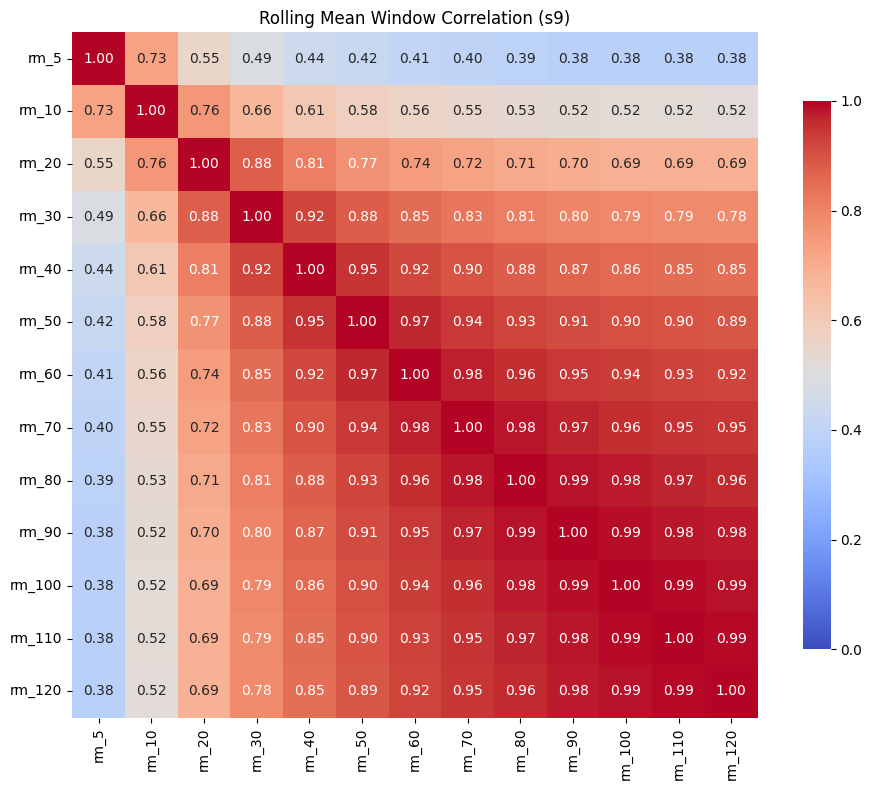

상관 0.95 이상 페어:
  rm_40 - rm_50: 0.951
  rm_50 - rm_60: 0.966
  rm_60 - rm_70: 0.976
  rm_60 - rm_80: 0.959
  rm_70 - rm_80: 0.982
  rm_70 - rm_90: 0.969
  rm_70 - rm_100: 0.959
  rm_70 - rm_110: 0.952
  rm_80 - rm_90: 0.987
  rm_80 - rm_100: 0.977
  rm_80 - rm_110: 0.970
  rm_80 - rm_120: 0.964
  rm_90 - rm_100: 0.990
  rm_90 - rm_110: 0.983
  rm_90 - rm_120: 0.977
  rm_100 - rm_110: 0.993
  rm_100 - rm_120: 0.987
  rm_110 - rm_120: 0.994


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (네 경로에 맞게 수정)
cols = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]
df = pd.read_csv('./CMAPSSData/train_FD002.txt', sep=r'\s+', header=None, names=cols)

# 2. 분석 대상 센서
target_sensor = 's9'  # 다른 센서로 바꿔서 반복 가능

# 3. 윈도우 리스트
windows = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

# 4. Rolling Mean 피처 생성
feat_df = pd.DataFrame()
for w in windows:
    feat_df[f'rm_{w}'] = (
        df.groupby('unit')[target_sensor]
          .transform(lambda x: x.rolling(w, min_periods=1).mean())
    )

# 5. 상관행렬
corr = feat_df.corr()

# 6. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=0, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title(f'Rolling Mean Window Correlation ({target_sensor})')
plt.tight_layout()
plt.show()

# 7. 상관 0.95 이상인 페어 출력 (redundant 윈도우 찾기)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i, j] > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
print("상관 0.95 이상 페어:")
for pair in high_corr:
    print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")

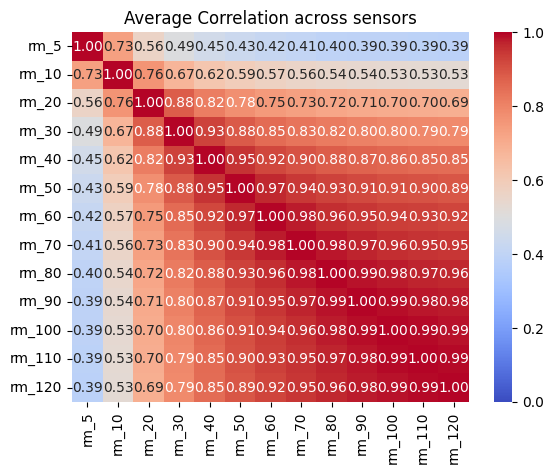

In [12]:
# 센서별로 corr 평균내기
sensors_to_check = ['s2', 's7', 's11', 's12', 's14', 's21']
all_corrs = []
for s in sensors_to_check:
    feat_df = pd.DataFrame()
    for w in windows:
        feat_df[f'rm_{w}'] = df.groupby('unit')[s].transform(
            lambda x: x.rolling(w, min_periods=1).mean())
    all_corrs.append(feat_df.corr())

avg_corr = sum(all_corrs) / len(all_corrs)
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Average Correlation across sensors')
plt.show()

## 6. 일반 실험 (기본 하이퍼파라미터)


 🏆 Ridge 평가 결과 (FD002)
 [Train] RMSE=12.5187 | MAE=9.3351 | R2=0.9168 | NASA=104208.9
 [Valid] RMSE=13.6821 | MAE=10.0742 | R2=0.9011 | NASA=37850.0
 [Test ] RMSE=24.2982 | MAE=18.0751 | R2=0.7959 | NASA=3927.1


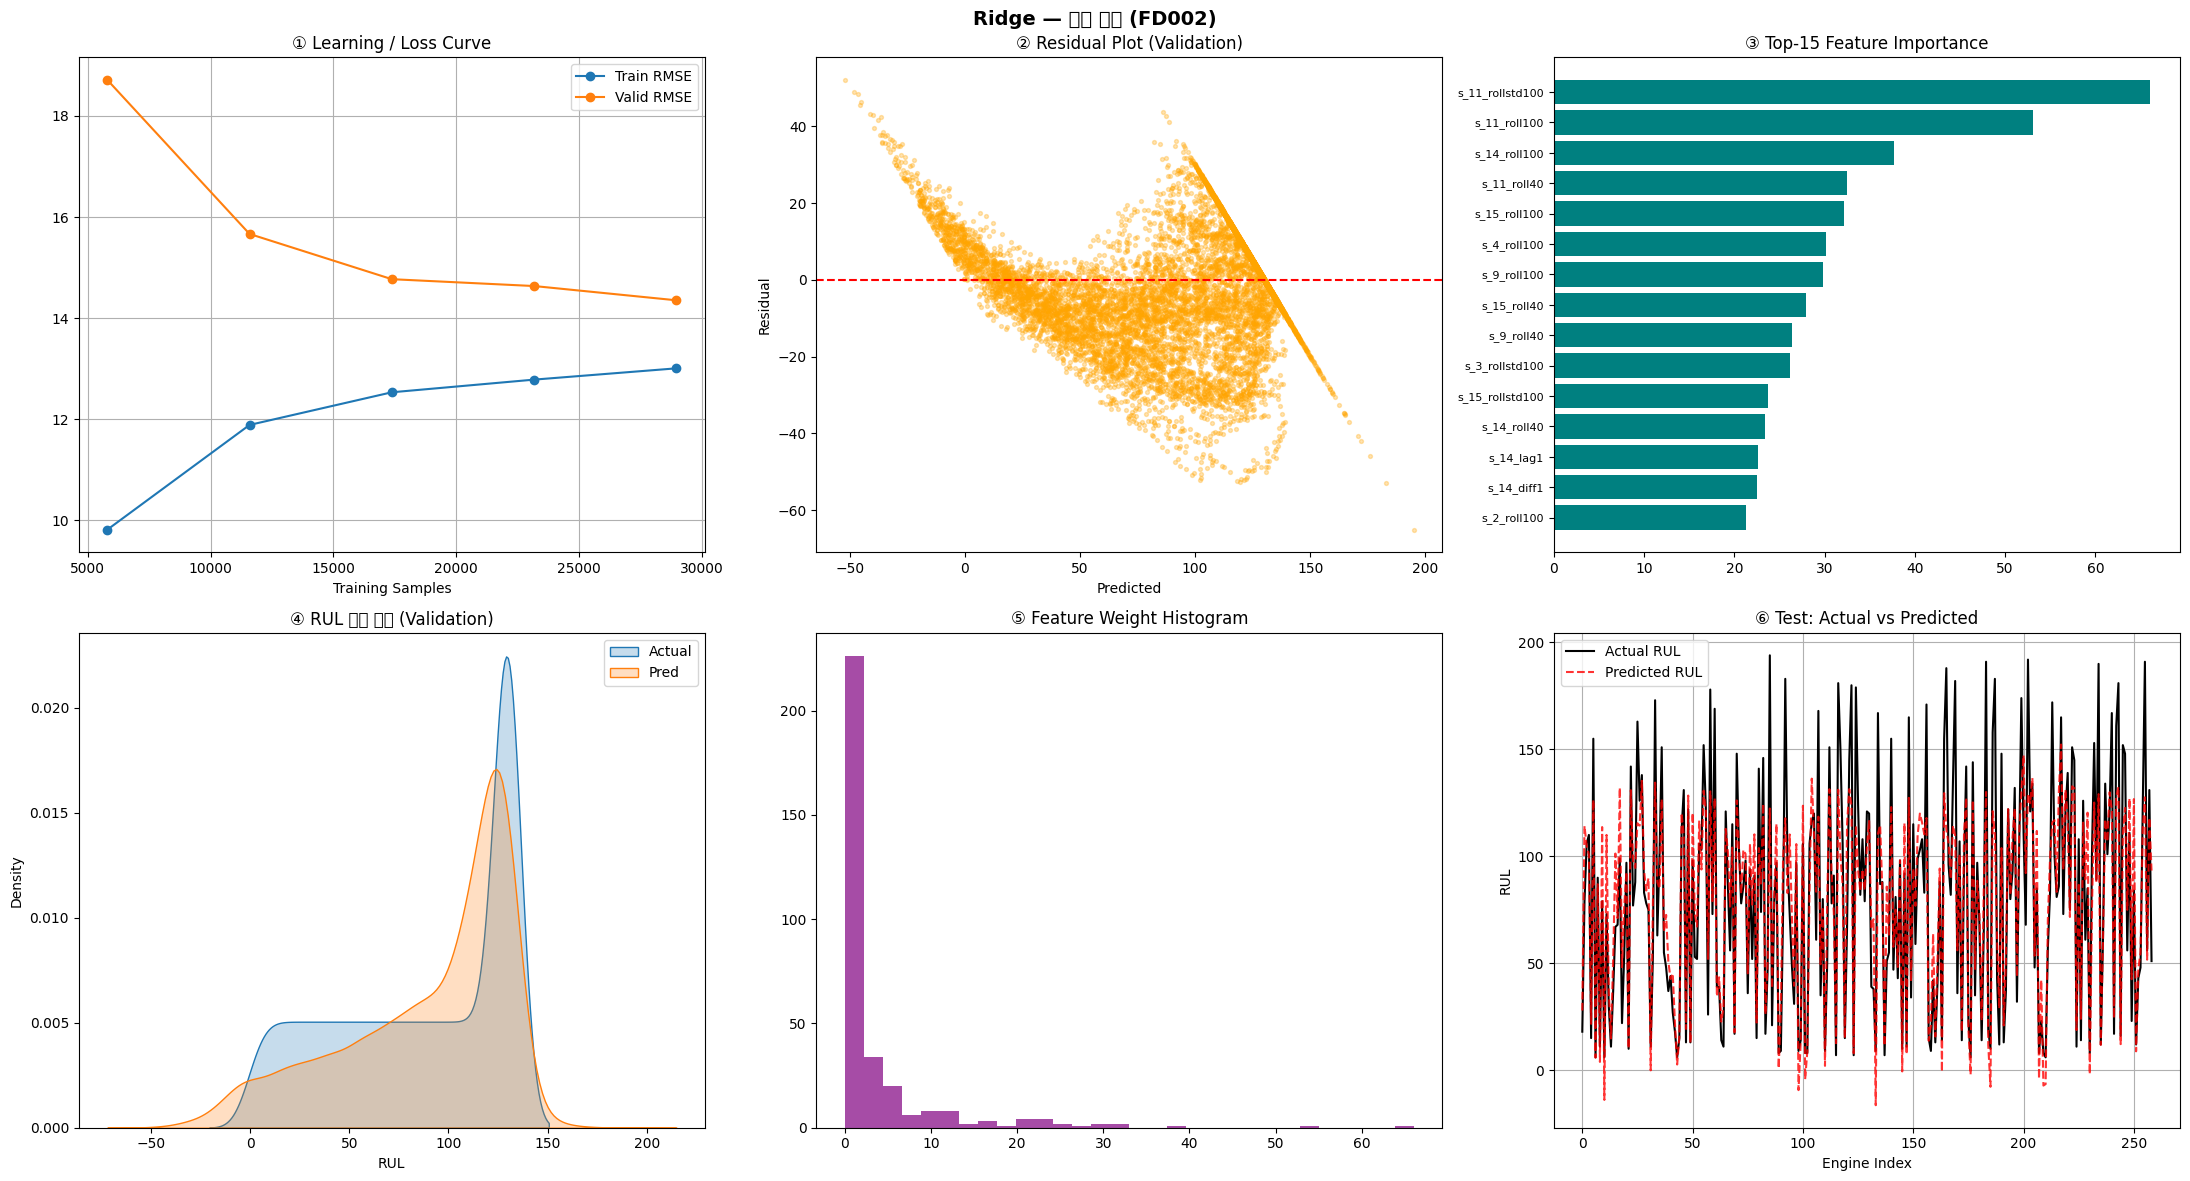

{'Train': {'RMSE': 12.518654301507004,
  'MAE': 9.335130164263159,
  'R2': 0.9168474098523226,
  'NASA_Score': 104208.87497913264},
 'Valid': {'RMSE': 13.682138291088355,
  'MAE': 10.074189694613901,
  'R2': 0.9010575124030744,
  'NASA_Score': 37850.04395632002},
 'Test': {'RMSE': 24.298241200724533,
  'MAE': 18.075113404028922,
  'R2': 0.7958602601226225,
  'NASA_Score': 3927.0766293755673}}

In [13]:
# ── Ridge ─────────────────────────────────────────────────────────────────
ridge_params = {'alpha': 1.0, 'solver': 'auto', 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_ridge  = Ridge(**ridge_params)
model_ridge.fit(X_train, y_train)
evaluate_full_pipeline(model_ridge, 'Ridge')


 🏆 Lasso 평가 결과 (FD002)
 [Train] RMSE=13.7156 | MAE=10.5697 | R2=0.9002 | NASA=132008.3
 [Valid] RMSE=13.8928 | MAE=10.4816 | R2=0.8980 | NASA=36689.2
 [Test ] RMSE=25.6605 | MAE=19.2429 | R2=0.7723 | NASA=4983.8


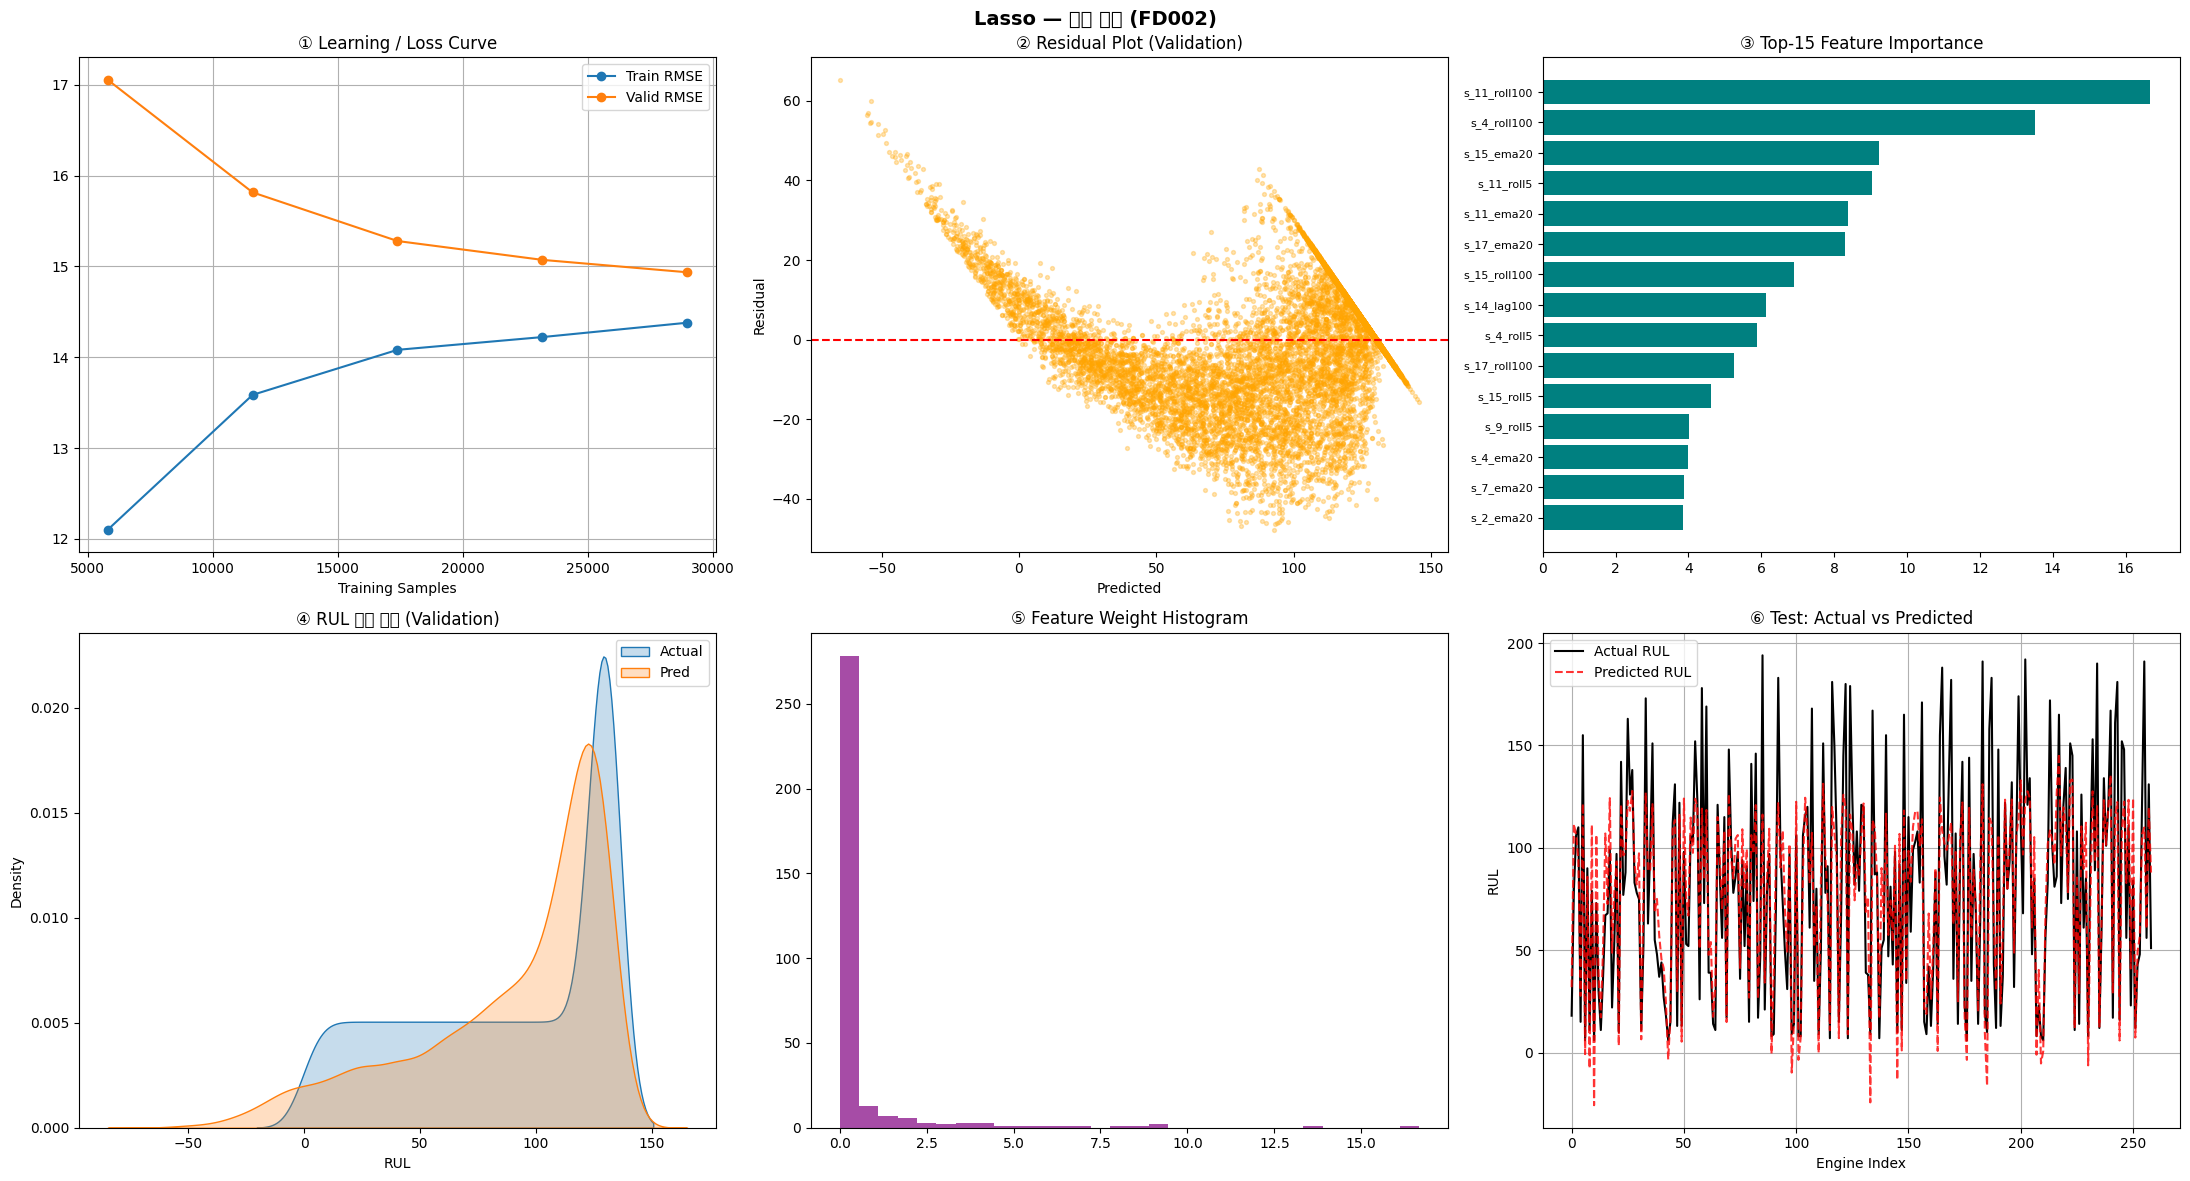

{'Train': {'RMSE': 13.715583384533753,
  'MAE': 10.569718423344613,
  'R2': 0.900186552081017,
  'NASA_Score': 132008.3013037634},
 'Valid': {'RMSE': 13.892802191716207,
  'MAE': 10.481607290885323,
  'R2': 0.8979872211261083,
  'NASA_Score': 36689.23647074911},
 'Test': {'RMSE': 25.660534348697574,
  'MAE': 19.2429123928484,
  'R2': 0.7723281844014493,
  'NASA_Score': 4983.80137445326}}

In [14]:
# ── Lasso ─────────────────────────────────────────────────────────────────
lasso_params = {'alpha': 0.1, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_lasso  = Lasso(**lasso_params)
model_lasso.fit(X_train, y_train)
evaluate_full_pipeline(model_lasso, 'Lasso')


 🏆 ElasticNet 평가 결과 (FD002)
 [Train] RMSE=14.1492 | MAE=10.8613 | R2=0.8938 | NASA=142444.2
 [Valid] RMSE=14.0940 | MAE=10.6014 | R2=0.8950 | NASA=37377.2
 [Test ] RMSE=25.8839 | MAE=19.3885 | R2=0.7683 | NASA=5261.9


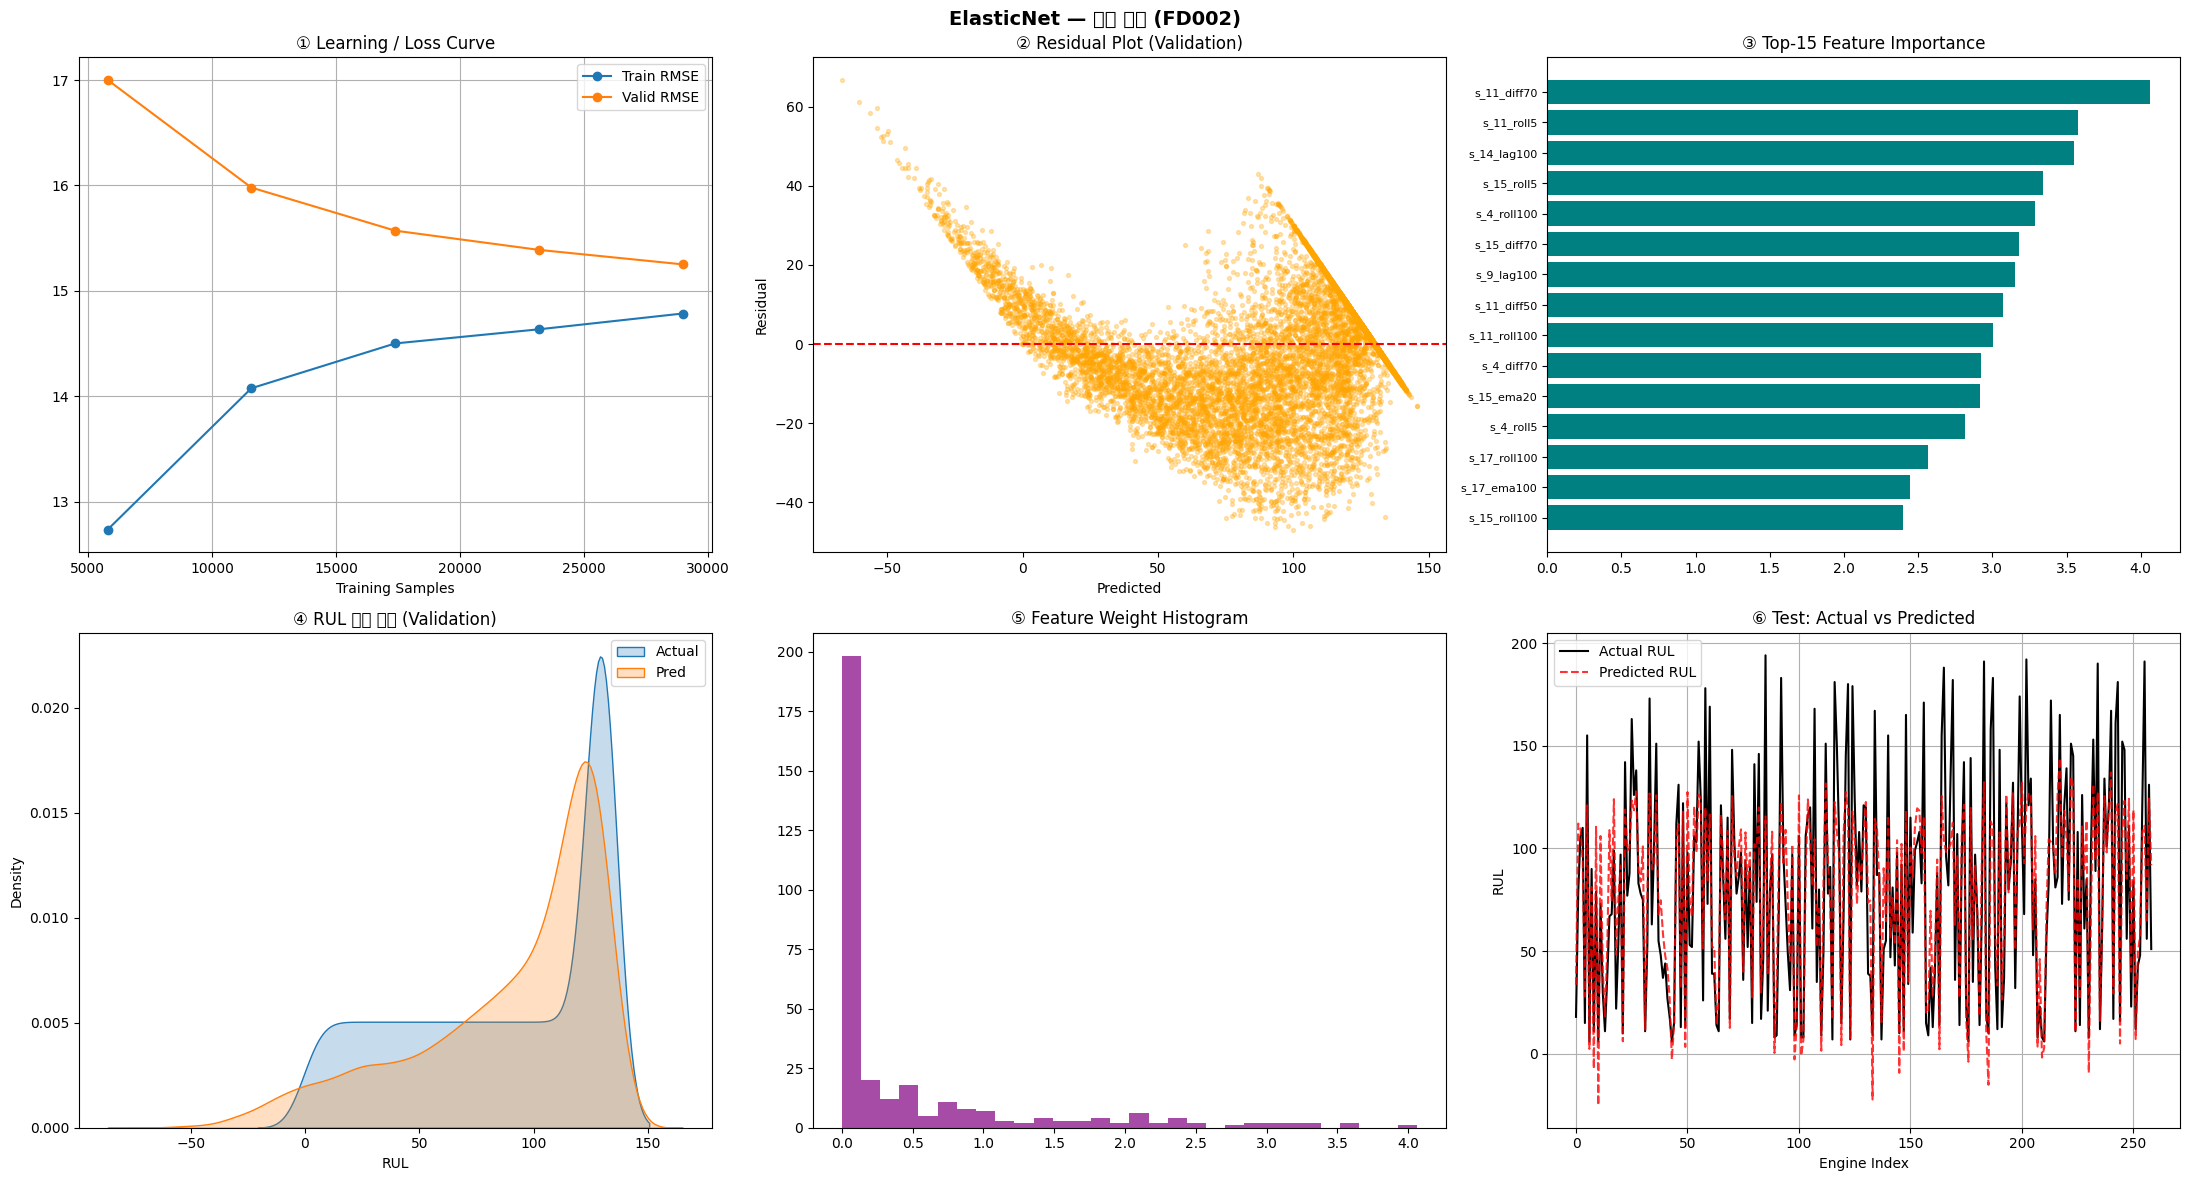

{'Train': {'RMSE': 14.149243323749022,
  'MAE': 10.861339168294002,
  'R2': 0.8937749562259732,
  'NASA_Score': 142444.18934782135},
 'Valid': {'RMSE': 14.093972202174822,
  'MAE': 10.601398944192237,
  'R2': 0.8950115086960843,
  'NASA_Score': 37377.24034729887},
 'Test': {'RMSE': 25.883900808045908,
  'MAE': 19.38854052982342,
  'R2': 0.7683473178032525,
  'NASA_Score': 5261.916599576223}}

In [15]:
# ── ElasticNet ────────────────────────────────────────────────────────────
elastic_params = {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_elastic  = ElasticNet(**elastic_params)
model_elastic.fit(X_train, y_train)
evaluate_full_pipeline(model_elastic, 'ElasticNet')


 🏆 RandomForest 평가 결과 (FD002)
 [Train] RMSE=8.9442 | MAE=6.3072 | R2=0.9576 | NASA=56955.9
 [Valid] RMSE=12.6728 | MAE=8.9177 | R2=0.9151 | NASA=32498.0
 [Test ] RMSE=24.3288 | MAE=16.3341 | R2=0.7953 | NASA=5193.5


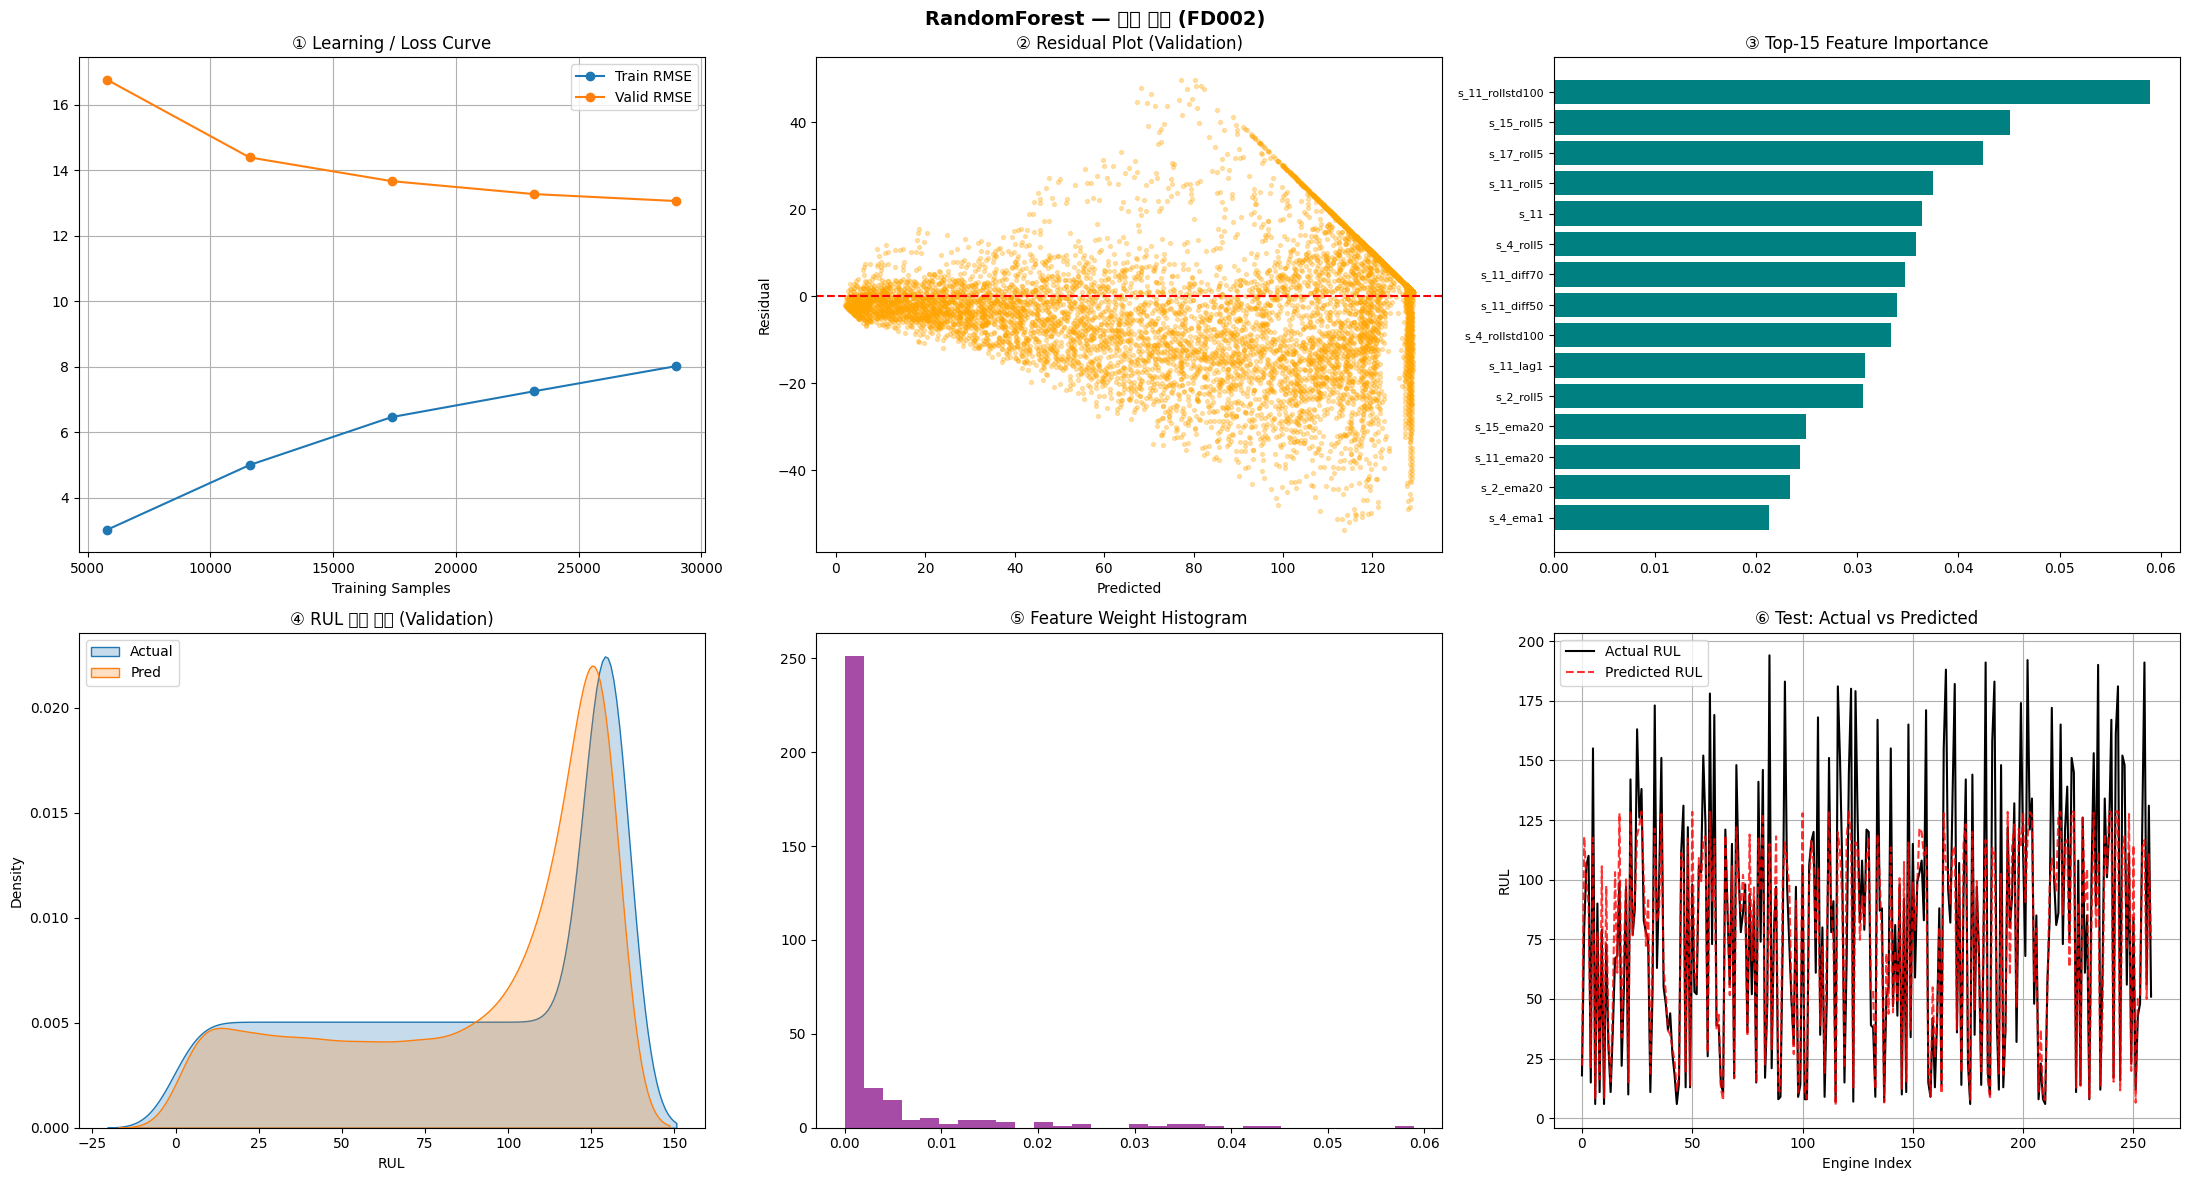

{'Train': {'RMSE': 8.944171445649607,
  'MAE': 6.307248930665341,
  'R2': 0.9575536140070784,
  'NASA_Score': 56955.93821166674},
 'Valid': {'RMSE': 12.672800265646426,
  'MAE': 8.917664335845144,
  'R2': 0.9151171302647232,
  'NASA_Score': 32498.015267993665},
 'Test': {'RMSE': 24.32879445419809,
  'MAE': 16.33411603249775,
  'R2': 0.7953465558974172,
  'NASA_Score': 5193.461834620618}}

In [16]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf_params = {
    'n_estimators': 200, 'max_depth': 10,
    'min_samples_split': 5, 'min_samples_leaf': 2,
    'max_features': 'sqrt', 'n_jobs': -1, 'random_state': RANDOM_STATE
}
model_rf = RandomForestRegressor(**rf_params)
model_rf.fit(X_train, y_train)
evaluate_full_pipeline(model_rf, 'RandomForest', is_tree=True)


 🏆 LightGBM 평가 결과 (FD002)
 [Train] RMSE=5.3969 | MAE=3.7322 | R2=0.9845 | NASA=22212.2
 [Valid] RMSE=11.8303 | MAE=8.0719 | R2=0.9260 | NASA=29085.3
 [Test ] RMSE=23.7972 | MAE=15.8729 | R2=0.8042 | NASA=4195.5


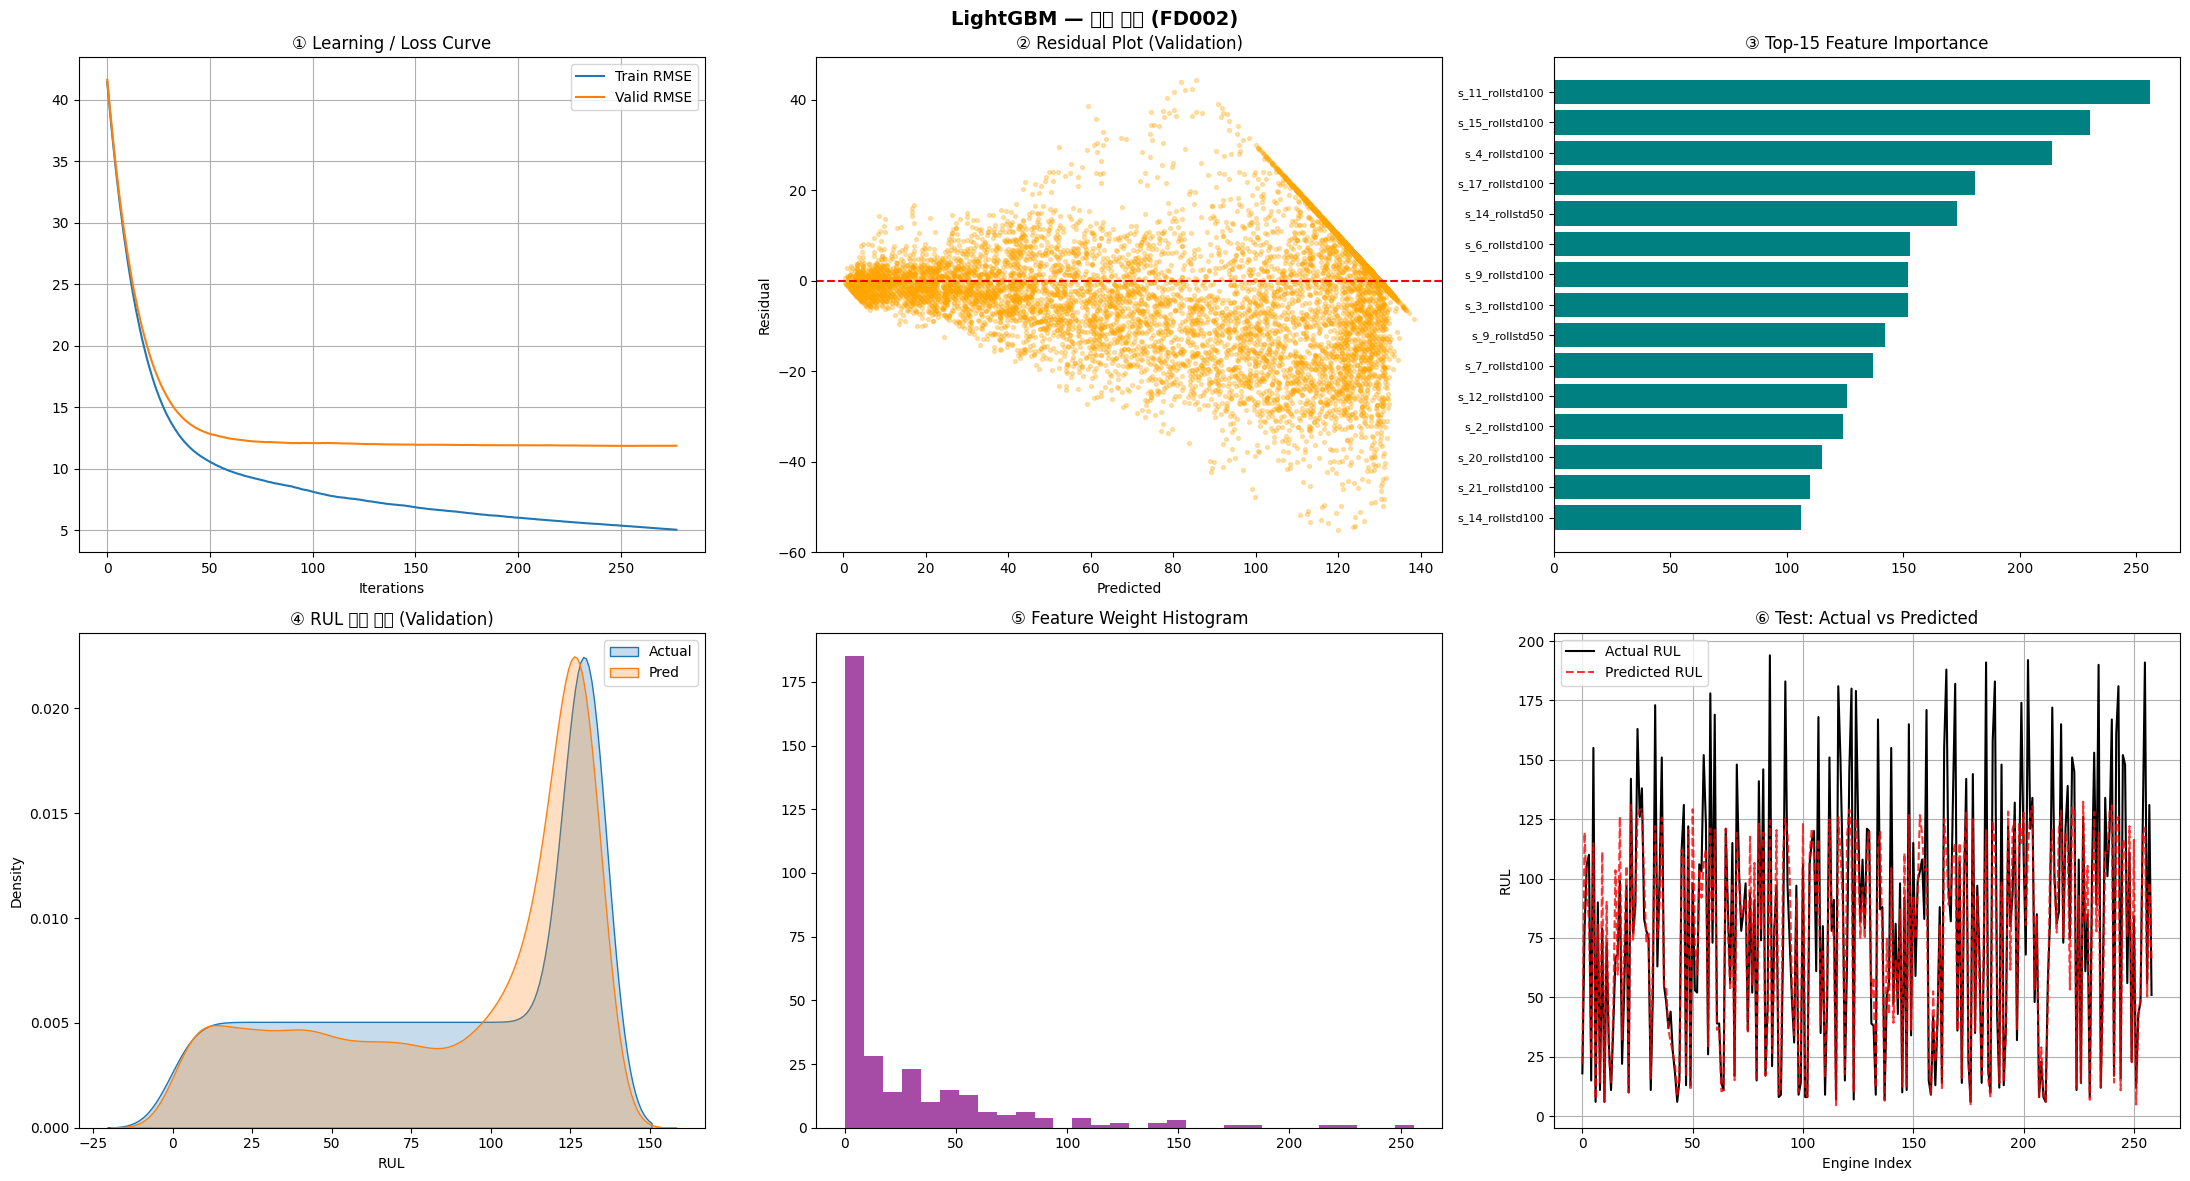

{'Train': {'RMSE': 5.3969498925385535,
  'MAE': 3.732202979067672,
  'R2': 0.9845454181070455,
  'NASA_Score': 22212.17818304432},
 'Valid': {'RMSE': 11.830291063897835,
  'MAE': 8.071922367894045,
  'R2': 0.9260282772273177,
  'NASA_Score': 29085.281710076888},
 'Test': {'RMSE': 23.79715047886104,
  'MAE': 15.872904681795186,
  'R2': 0.8041931896069412,
  'NASA_Score': 4195.525913220609}}

In [17]:
# ── LightGBM ──────────────────────────────────────────────────────────────
lgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05,
    'max_depth': 6, 'num_leaves': 31,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'device': LGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1
}
model_lgb = lgb.LGBMRegressor(**lgb_params)
model_lgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

res_lgb = model_lgb.evals_result_
train_key = 'training' if 'training' in res_lgb else 'valid_0'
m_key = 'rmse' if 'rmse' in res_lgb[train_key] else list(res_lgb[train_key].keys())[0]
eval_dict_lgb = {'train': res_lgb[train_key][m_key],
                 'valid': res_lgb['valid_1'][m_key]}
evaluate_full_pipeline(model_lgb, 'LightGBM', is_tree=True,
                       is_boosting=True, eval_results=eval_dict_lgb)


 🏆 XGBoost 평가 결과 (FD002)
 [Train] RMSE=2.6436 | MAE=1.8195 | R2=0.9963 | NASA=8412.0
 [Valid] RMSE=11.9497 | MAE=8.1678 | R2=0.9245 | NASA=29015.8
 [Test ] RMSE=23.7467 | MAE=15.9906 | R2=0.8050 | NASA=4043.7


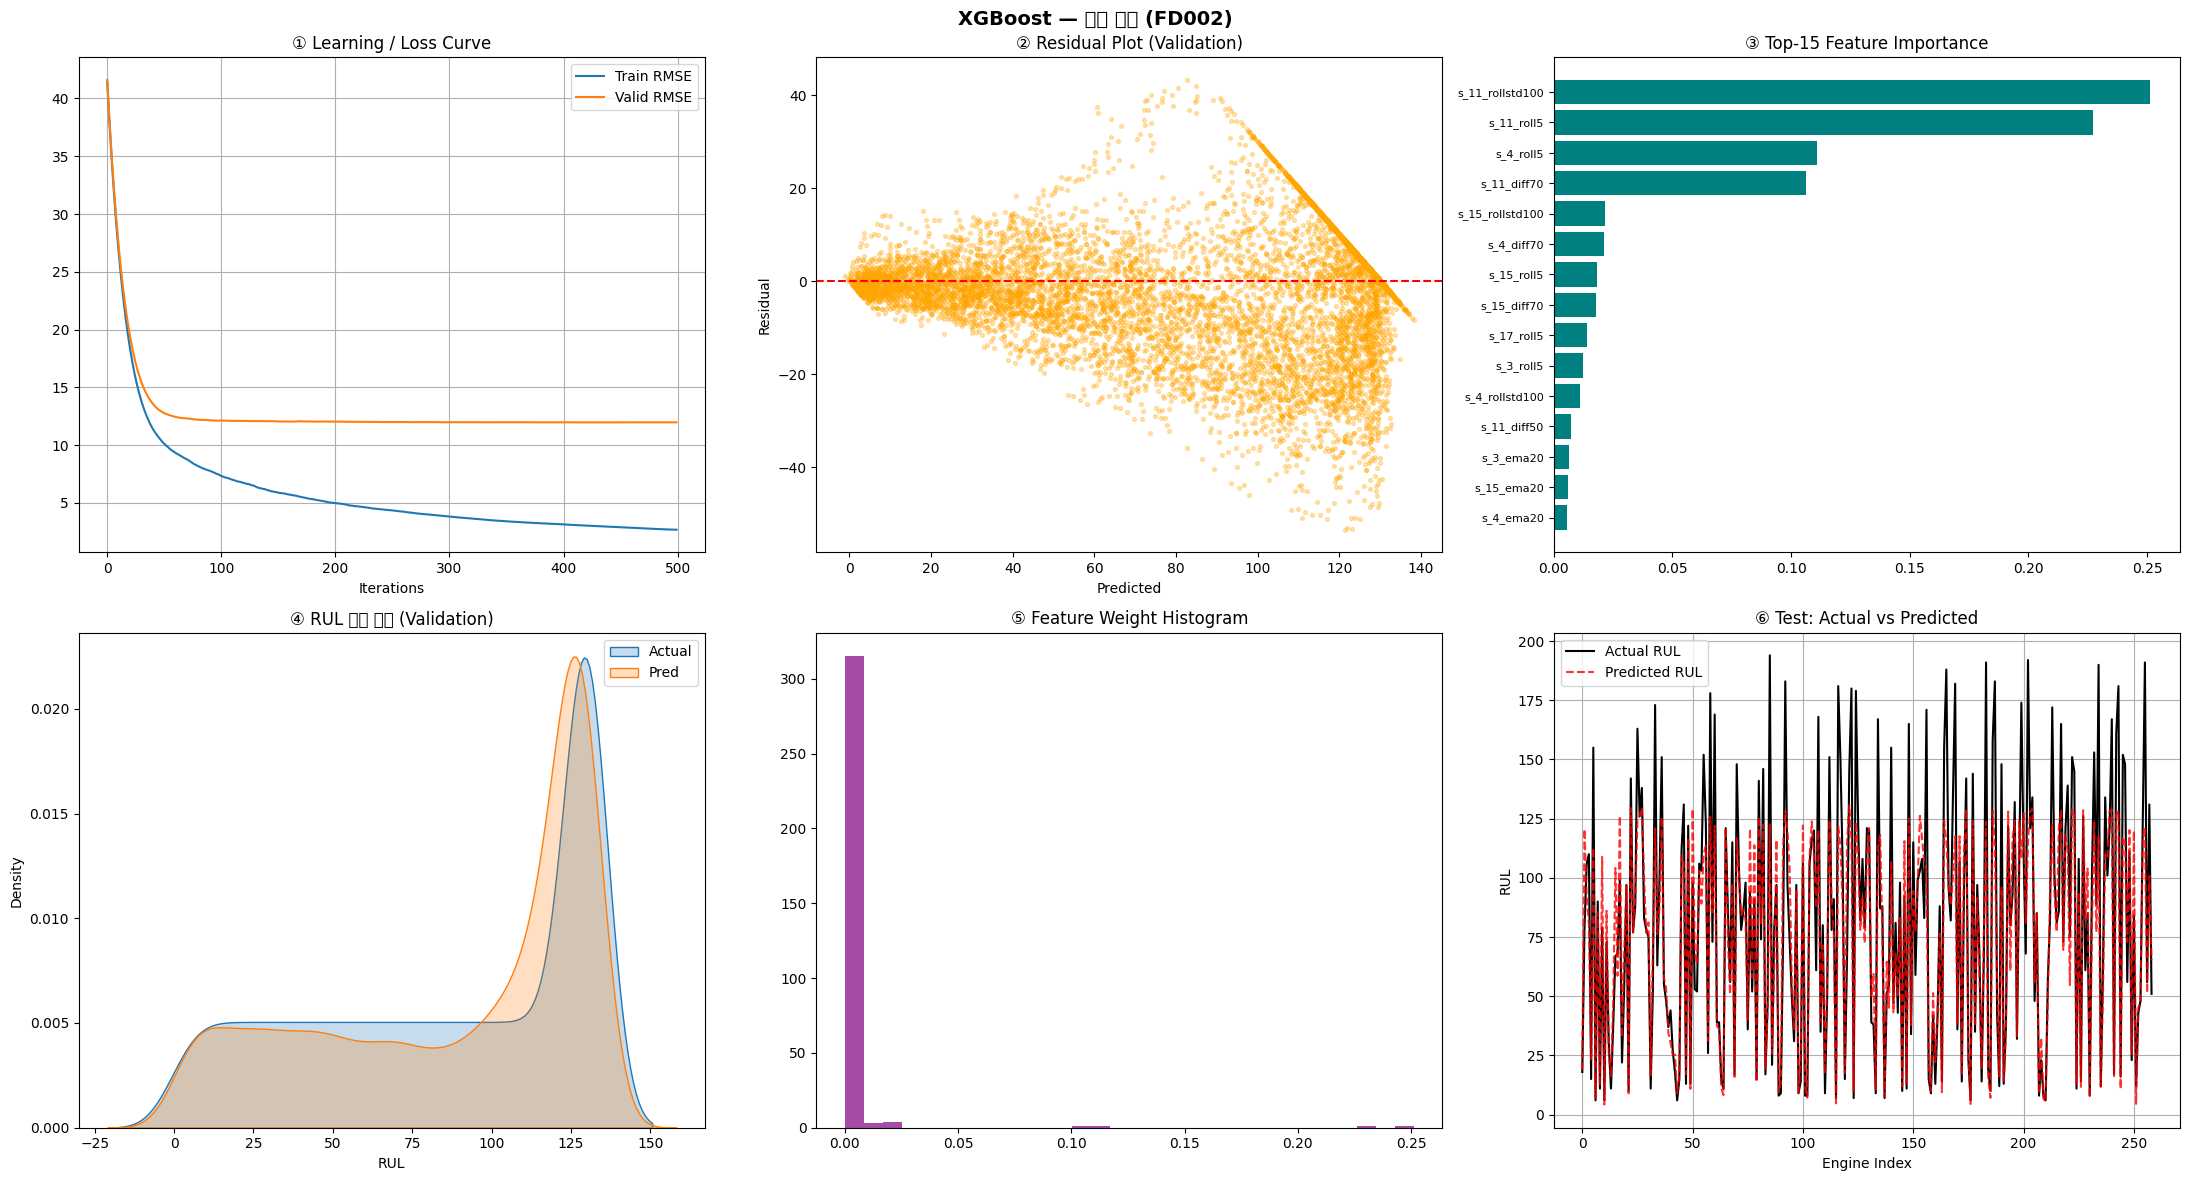

{'Train': {'RMSE': 2.64355532160526,
  'MAE': 1.8195314896209847,
  'R2': 0.9962920207516174,
  'NASA_Score': 8411.997895047141},
 'Valid': {'RMSE': 11.94971753965631,
  'MAE': 8.167827592491236,
  'R2': 0.9245272537062035,
  'NASA_Score': 29015.81798390136},
 'Test': {'RMSE': 23.746697909080442,
  'MAE': 15.990627097347067,
  'R2': 0.8050225733213958,
  'NASA_Score': 4043.7002407689833}}

In [18]:
# ── XGBoost ───────────────────────────────────────────────────────────────
xgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'tree_method': 'hist', 'device': XGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0
}
model_xgb = xgb.XGBRegressor(**xgb_params)
model_xgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)], verbose=False)
res_xgb = model_xgb.evals_result()
eval_dict_xgb = {'train': res_xgb['validation_0']['rmse'],
                 'valid': res_xgb['validation_1']['rmse']}
evaluate_full_pipeline(model_xgb, 'XGBoost', is_tree=True,
                       is_boosting=True, eval_results=eval_dict_xgb)

In [19]:
# === 누수 진단: 예측 잔차 분석 ===
for mname, m in [('Ridge', model_ridge), ('LGBM', model_lgb), ('XGB', model_xgb)]:
    pred = np.clip(m.predict(X_test), 0, CONFIG['rul_cap'])
    d = pred - y_test
    print(f'\n[{mname}] pred: min={pred.min():.1f} max={pred.max():.1f} mean={pred.mean():.1f}')
    print(f'         잔차 음수(보수적): {(d<0).mean():.1%}')
    print(f'         잔차 양수(낙관적): {(d>0).mean():.1%}')
    print(f'         |d| 평균: {np.abs(d).mean():.2f}')

# 음수 비율이 70% 이상이면 정상적으로 잘 나온 거. 50:50인데 NASA가 200대면 누수


[Ridge] pred: min=0.0 max=130.0 mean=79.2
         잔차 음수(보수적): 45.9%
         잔차 양수(낙관적): 54.1%
         |d| 평균: 18.08

[LGBM] pred: min=4.6 max=130.0 mean=75.4
         잔차 음수(보수적): 54.1%
         잔차 양수(낙관적): 45.9%
         |d| 평균: 15.87

[XGB] pred: min=4.0 max=130.0 mean=75.4
         잔차 음수(보수적): 52.9%
         잔차 양수(낙관적): 47.1%
         |d| 평균: 15.99


## 7. Optuna 튜닝 설정

In [20]:
# ============================================================
# ⚙️ OPTUNA 설정
# ============================================================
N_TRIALS_LIN    = 30      # 선형 모델
N_TRIALS_TREE   = 50      # 트리 모델
OPTUNA_METRIC   = 'rmse'  # 'rmse' | 'nasa'
N_SPLITS        = 5       # GroupKFold (엔진 단위)
INNER_VAL_RATIO = 0.15    # ES용 inner-val 비율

groups = train_ml['unit_nr'].values
gkf    = GroupKFold(n_splits=N_SPLITS)

ALL_RESULTS = {}
BEST_MODELS = {}

# ── 헬퍼 ──────────────────────────────────────────────────────────────────
def clip_rul(pred, cap=CONFIG['rul_cap']):
    return np.clip(pred, 0, cap)

def cv_score(builder, X, y, grp, metric=OPTUNA_METRIC):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        m = builder()
        m.fit(X.iloc[ti], y.iloc[ti])
        pred = clip_rul(m.predict(X.iloc[vi]))
        rmse_list.append(float(np.sqrt(mean_squared_error(y.iloc[vi], pred))))
        nasa_list.append(float(calculate_nasa_score(y.iloc[vi], pred) / max(len(y.iloc[vi]), 1)))
    return {'cv_rmse_mean': float(np.mean(rmse_list)),
            'cv_nasa_mean': float(np.mean(nasa_list))}

def _inner_split(X, y, grp, val_ratio=INNER_VAL_RATIO, seed=RANDOM_STATE):
    rng   = np.random.default_rng(seed)
    units = np.array(sorted(set(grp)))
    rng.shuffle(units)
    n_va  = max(1, int(len(units) * val_ratio))
    va_set = set(units[:n_va])
    mask   = np.array([g in va_set for g in grp])
    return X[~mask], y[~mask], X[mask], y[mask]

def _fit_with_es(model, name, Xtr, ytr, Xva=None, yva=None):
    if name == 'RandomForest' or Xva is None:
        model.fit(Xtr, ytr)
    elif name == 'XGBoost':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    elif name == 'LightGBM':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)],
                  callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

def cv_score_es(builder, X, y, grp, name, metric=OPTUNA_METRIC):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        Xtr_f = X.iloc[ti]; ytr_f = y.iloc[ti]
        Xva   = X.iloc[vi]; yva   = y.iloc[vi]
        model = builder()
        if name in ('XGBoost', 'LightGBM'):
            X_in, y_in, X_iv, y_iv = _inner_split(
                Xtr_f.values, ytr_f.values, grp[ti])
            X_in = pd.DataFrame(X_in, columns=X.columns)
            X_iv = pd.DataFrame(X_iv, columns=X.columns)
            _fit_with_es(model, name, X_in, pd.Series(y_in), X_iv, pd.Series(y_iv))
        else:
            _fit_with_es(model, name, Xtr_f, ytr_f)
        pred = clip_rul(model.predict(Xva))
        rmse_list.append(float(np.sqrt(mean_squared_error(yva, pred))))
        nasa_list.append(float(calculate_nasa_score(yva, pred) / max(len(yva), 1)))
    return {'cv_rmse_mean': float(np.mean(rmse_list)),
            'cv_rmse_std' : float(np.std(rmse_list)),
            'cv_nasa_mean': float(np.mean(nasa_list))}

print('✅ Optuna 설정 완료')
print(f'   N_TRIALS: 선형={N_TRIALS_LIN} / 트리={N_TRIALS_TREE}')
print(f'   Metric  : {OPTUNA_METRIC.upper()} | CV splits: {N_SPLITS} (GroupKFold by unit_nr)')

✅ Optuna 설정 완료
   N_TRIALS: 선형=30 / 트리=50
   Metric  : RMSE | CV splits: 5 (GroupKFold by unit_nr)


## 8. Optuna — 선형 모델 (Ridge / Lasso / ElasticNet)

In [21]:
def _build_linear(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True),
                     solver=trial.suggest_categorical('solver', ['auto','svd','cholesky','lsqr']),
                     max_iter=3000, random_state=RANDOM_STATE)
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
                     selection=trial.suggest_categorical('selection', ['cyclic','random']),
                     max_iter=3000, tol=0.001, random_state=RANDOM_STATE)
    elif name == 'ElasticNet':
        return ElasticNet(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
                          l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95),
                          selection=trial.suggest_categorical('selection', ['cyclic','random']),
                          max_iter=3000, tol=0.001, random_state=RANDOM_STATE)
    raise ValueError(name)

for mname in ['Ridge', 'Lasso', 'ElasticNet']:
    t0 = time.time()
    print(f'[{mname}] 최적화 시작 ... ({N_TRIALS_LIN} trials)', end='', flush=True)

    def _obj_lin(trial, _m=mname):
        res = cv_score(lambda: _build_linear(trial, _m), X_train, y_train, groups)
        return res['cv_nasa_mean'] if OPTUNA_METRIC == 'nasa' else res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(_obj_lin, n_trials=N_TRIALS_LIN, show_progress_bar=False)

    best_p = study.best_params
    best_m = _build_linear(optuna.trial.FixedTrial(best_p), mname)
    best_m.fit(X_train, y_train)

    cv_res    = cv_score(lambda: _build_linear(optuna.trial.FixedTrial(best_p), mname),
                         X_train, y_train, groups)
    val_mets  = get_metrics(y_val,  best_m.predict(X_val))
    test_mets = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'type':'linear', 'model':best_m, 'params':best_p,
        'cv_rmse':cv_res['cv_rmse_mean'], 'cv_nasa':cv_res['cv_nasa_mean'],
        'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
    }
    BEST_MODELS[mname] = best_m

    print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f} '
          f'| Val RMSE={val_mets["RMSE"]:.3f} '
          f'| Test NASA={test_mets["NASA_Score"]:.1f} '
          f'| {time.time()-t0:.0f}s')
    print(f'   best_params: {best_p}')

print('\n✅ 선형 모델 최적화 완료')

[Ridge] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=13.317 | Val RMSE=13.687 | Test NASA=3942.4 | 52s
   best_params: {'alpha': 3.764984064353955, 'solver': 'lsqr'}
[Lasso] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=13.273 | Val RMSE=13.657 | Test NASA=3923.5 | 17933s
   best_params: {'alpha': 0.005702567263477803, 'selection': 'cyclic'}
[ElasticNet] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=13.303 | Val RMSE=13.669 | Test NASA=3990.4 | 19770s
   best_params: {'alpha': 0.0017722751943993484, 'l1_ratio': 0.8354893797801306, 'selection': 'random'}

✅ 선형 모델 최적화 완료


## 9. Optuna — RandomForest (CPU)

In [28]:
def _build_rf(trial):
    return RandomForestRegressor(
        n_estimators      = trial.suggest_int  ('n_estimators',    100, 600),
        max_depth         = trial.suggest_int  ('max_depth',         5,  30),
        min_samples_split = trial.suggest_int  ('min_samples_split', 2,  20),
        min_samples_leaf  = trial.suggest_int  ('min_samples_leaf',  1,  10),
        max_features      = trial.suggest_float('max_features',     0.2, 1.0),
        random_state=RANDOM_STATE, n_jobs=-1)

t0 = time.time()
print(f'[RandomForest] 최적화 시작 ... ({N_TRIALS_TREE} trials)')

study_rf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_rf.optimize(
    lambda t: cv_score_es(lambda: _build_rf(t), X_train, y_train, groups, 'RandomForest')
             ['cv_nasa_mean' if OPTUNA_METRIC=='nasa' else 'cv_rmse_mean'],
    n_trials=N_TRIALS_TREE, show_progress_bar=False)

best_p = study_rf.best_params
best_m = _build_rf(optuna.trial.FixedTrial(best_p))
best_m.fit(X_train, y_train)

cv_res    = cv_score_es(lambda: _build_rf(optuna.trial.FixedTrial(best_p)),
                         X_train, y_train, groups, 'RandomForest')
val_mets  = get_metrics(y_val,  best_m.predict(X_val))
test_mets = get_metrics(y_test, best_m.predict(X_test))

ALL_RESULTS['RandomForest'] = {
    'type':'tree', 'model':best_m, 'params':best_p,
    'cv_rmse':cv_res['cv_rmse_mean'], 'cv_rmse_std':cv_res['cv_rmse_std'],
    'cv_nasa':cv_res['cv_nasa_mean'],
    'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
}
BEST_MODELS['RandomForest'] = best_m

print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_mets["RMSE"]:.3f} '
      f'| Test NASA={test_mets["NASA_Score"]:.1f} | {time.time()-t0:.0f}s')
print(f'   best_params: {best_p}')

[RandomForest] 최적화 시작 ... (50 trials)
  ✅ | CV RMSE=12.231 | Val RMSE=12.383 | Test NASA=4538.6 | 7452s
   best_params: {'n_estimators': 422, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 0.24948116251735444}


## 10. Optuna — XGBoost / LightGBM (GPU 자동)

In [23]:
def _build_boost(trial, name):
    if name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators          = trial.suggest_int  ('n_estimators',     150, 700),
            max_depth             = trial.suggest_int  ('max_depth',          3,  10),
            learning_rate         = trial.suggest_float('learning_rate',   0.01, 0.3,  log=True),
            subsample             = trial.suggest_float('subsample',        0.5, 1.0),
            colsample_bytree      = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha             = trial.suggest_float('reg_alpha',       1e-8,  10,  log=True),
            reg_lambda            = trial.suggest_float('reg_lambda',      1e-8,  10,  log=True),
            early_stopping_rounds = 30,
            tree_method='hist', device=XGB_DEVICE,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    elif name == 'LightGBM':
        return lgb.LGBMRegressor(
            n_estimators     = trial.suggest_int  ('n_estimators',    150, 700),
            max_depth        = trial.suggest_int  ('max_depth',         3,  12),
            learning_rate    = trial.suggest_float('learning_rate',  0.01, 0.3,  log=True),
            num_leaves       = trial.suggest_int  ('num_leaves',       15, 255),
            subsample        = trial.suggest_float('subsample',       0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree',0.5, 1.0),
            reg_alpha        = trial.suggest_float('reg_alpha',      1e-8,  10,  log=True),
            reg_lambda       = trial.suggest_float('reg_lambda',     1e-8,  10,  log=True),
            device=LGB_DEVICE, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    raise ValueError(name)

for mname in ['XGBoost', 'LightGBM']:
    t0  = time.time()
    dev = XGB_DEVICE if mname == 'XGBoost' else LGB_DEVICE
    print(f'[{mname}] 최적화 시작 ... ({N_TRIALS_TREE} trials) | device={dev}')

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(
        lambda t, _m=mname: cv_score_es(lambda: _build_boost(t, _m), X_train, y_train, groups, _m)
                            ['cv_nasa_mean' if OPTUNA_METRIC=='nasa' else 'cv_rmse_mean'],
        n_trials=N_TRIALS_TREE, show_progress_bar=False)

    best_p = study.best_params
    best_m = _build_boost(optuna.trial.FixedTrial(best_p), mname)

    X_in, y_in, X_iv, y_iv = _inner_split(X_train.values, y_train.values, groups)
    X_in = pd.DataFrame(X_in, columns=ML_FEATURES)
    X_iv = pd.DataFrame(X_iv, columns=ML_FEATURES)
    _fit_with_es(best_m, mname, X_in, pd.Series(y_in), X_iv, pd.Series(y_iv))

    cv_res    = cv_score_es(lambda: _build_boost(optuna.trial.FixedTrial(best_p), mname),
                             X_train, y_train, groups, mname)
    val_mets  = get_metrics(y_val,  best_m.predict(X_val))
    test_mets = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'type':'tree', 'model':best_m, 'params':best_p,
        'cv_rmse':cv_res['cv_rmse_mean'], 'cv_rmse_std':cv_res['cv_rmse_std'],
        'cv_nasa':cv_res['cv_nasa_mean'],
        'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
    }
    BEST_MODELS[mname] = best_m

    print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f}±{cv_res["cv_rmse_std"]:.3f} '
          f'| Val RMSE={val_mets["RMSE"]:.3f} '
          f'| Test NASA={test_mets["NASA_Score"]:.1f} '
          f'| {time.time()-t0:.0f}s')
    print(f'   best_params: {best_p}')

print('\n✅ Boosting 모델 최적화 완료')

[XGBoost] 최적화 시작 ... (50 trials) | device=cuda
  ✅ | CV RMSE=12.141±0.490 | Val RMSE=11.953 | Test NASA=4198.5 | 580s
   best_params: {'n_estimators': 621, 'max_depth': 6, 'learning_rate': 0.017491747763580135, 'subsample': 0.5496424269188376, 'colsample_bytree': 0.5140859759307262, 'reg_alpha': 0.6759193998482651, 'reg_lambda': 0.0029559850179357357}
[LightGBM] 최적화 시작 ... (50 trials) | device=gpu
  ✅ | CV RMSE=12.235±0.461 | Val RMSE=11.900 | Test NASA=4287.5 | 912s
   best_params: {'n_estimators': 677, 'max_depth': 6, 'learning_rate': 0.010775228020342231, 'num_leaves': 181, 'subsample': 0.605081846741258, 'colsample_bytree': 0.5488007912473831, 'reg_alpha': 0.0003747128797117446, 'reg_lambda': 1.4051040874661587e-06}

✅ Boosting 모델 최적화 완료


## 11. 전체 모델 비교표

In [29]:
rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        'Model'    : mname,
        'CV_RMSE'  : round(res['cv_rmse'], 4),
        'Val_RMSE' : round(res['val_metrics']['RMSE'], 4),
        'Val_NASA' : round(res['val_metrics']['NASA_Score'], 1),
        'Test_RMSE': round(res['test_metrics']['RMSE'], 4),
        'Test_NASA': round(res['test_metrics']['NASA_Score'], 1),
        'Test_R2'  : round(res['test_metrics']['R2'], 4),
        'Time(s)'  : round(res['fit_seconds'], 1),
    })

summary_df = pd.DataFrame(rows).sort_values('Test_RMSE').reset_index(drop=True)
print('\n' + '='*70)
print(f'📊 모델 성능 비교표 — {CONFIG['subset']} (Test RMSE 기준 정렬)')##
print('='*70)
print(summary_df.to_string(index=False))
print('='*70)

best_name = summary_df.iloc[0]['Model']
print(f'\n🏆 최고 성능 모델: {best_name}')
print(f'   Test RMSE  = {summary_df.iloc[0]["Test_RMSE"]}')
print(f'   Test NASA  = {summary_df.iloc[0]["Test_NASA"]}')
print(f'   Test R²    = {summary_df.iloc[0]["Test_R2"]}')


📊 모델 성능 비교표 — FD002 (Test RMSE 기준 정렬)
       Model  CV_RMSE  Val_RMSE   Val_NASA  Test_RMSE  Test_NASA  Test_R2    Time(s)
     XGBoost  12.1405   11.9530 29124.7000    23.6226  4198.5000   0.8071   579.8000
    LightGBM  12.2349   11.8997 28789.1000    23.7768  4287.5000   0.8045   911.7000
RandomForest  12.2309   12.3833 32438.2000    23.9931  4538.6000   0.8010  7451.8000
       Ridge  13.3173   13.6874 37887.2000    24.3281  3942.4000   0.7954    52.0000
       Lasso  13.2729   13.6573 37709.7000    24.3514  3923.5000   0.7950 17933.0000
  ElasticNet  13.3028   13.6687 37501.2000    24.4181  3990.4000   0.7938 19770.0000

🏆 최고 성능 모델: XGBoost
   Test RMSE  = 23.6226
   Test NASA  = 4198.5
   Test R²    = 0.8071



🌲 [RandomForest] 모델 재평가 및 시각화 시작
🎯 최적 파라미터: {'n_estimators': 422, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 0.24948116251735444}

 🏆 RandomForest (Optuna 최적) 평가 결과 (FD002)
 [Train] RMSE=8.5130 | MAE=5.9083 | R2=0.9615 | NASA=53464.1
 [Valid] RMSE=12.3833 | MAE=8.5304 | R2=0.9190 | NASA=32438.2
 [Test ] RMSE=23.9931 | MAE=16.1117 | R2=0.8010 | NASA=4538.6


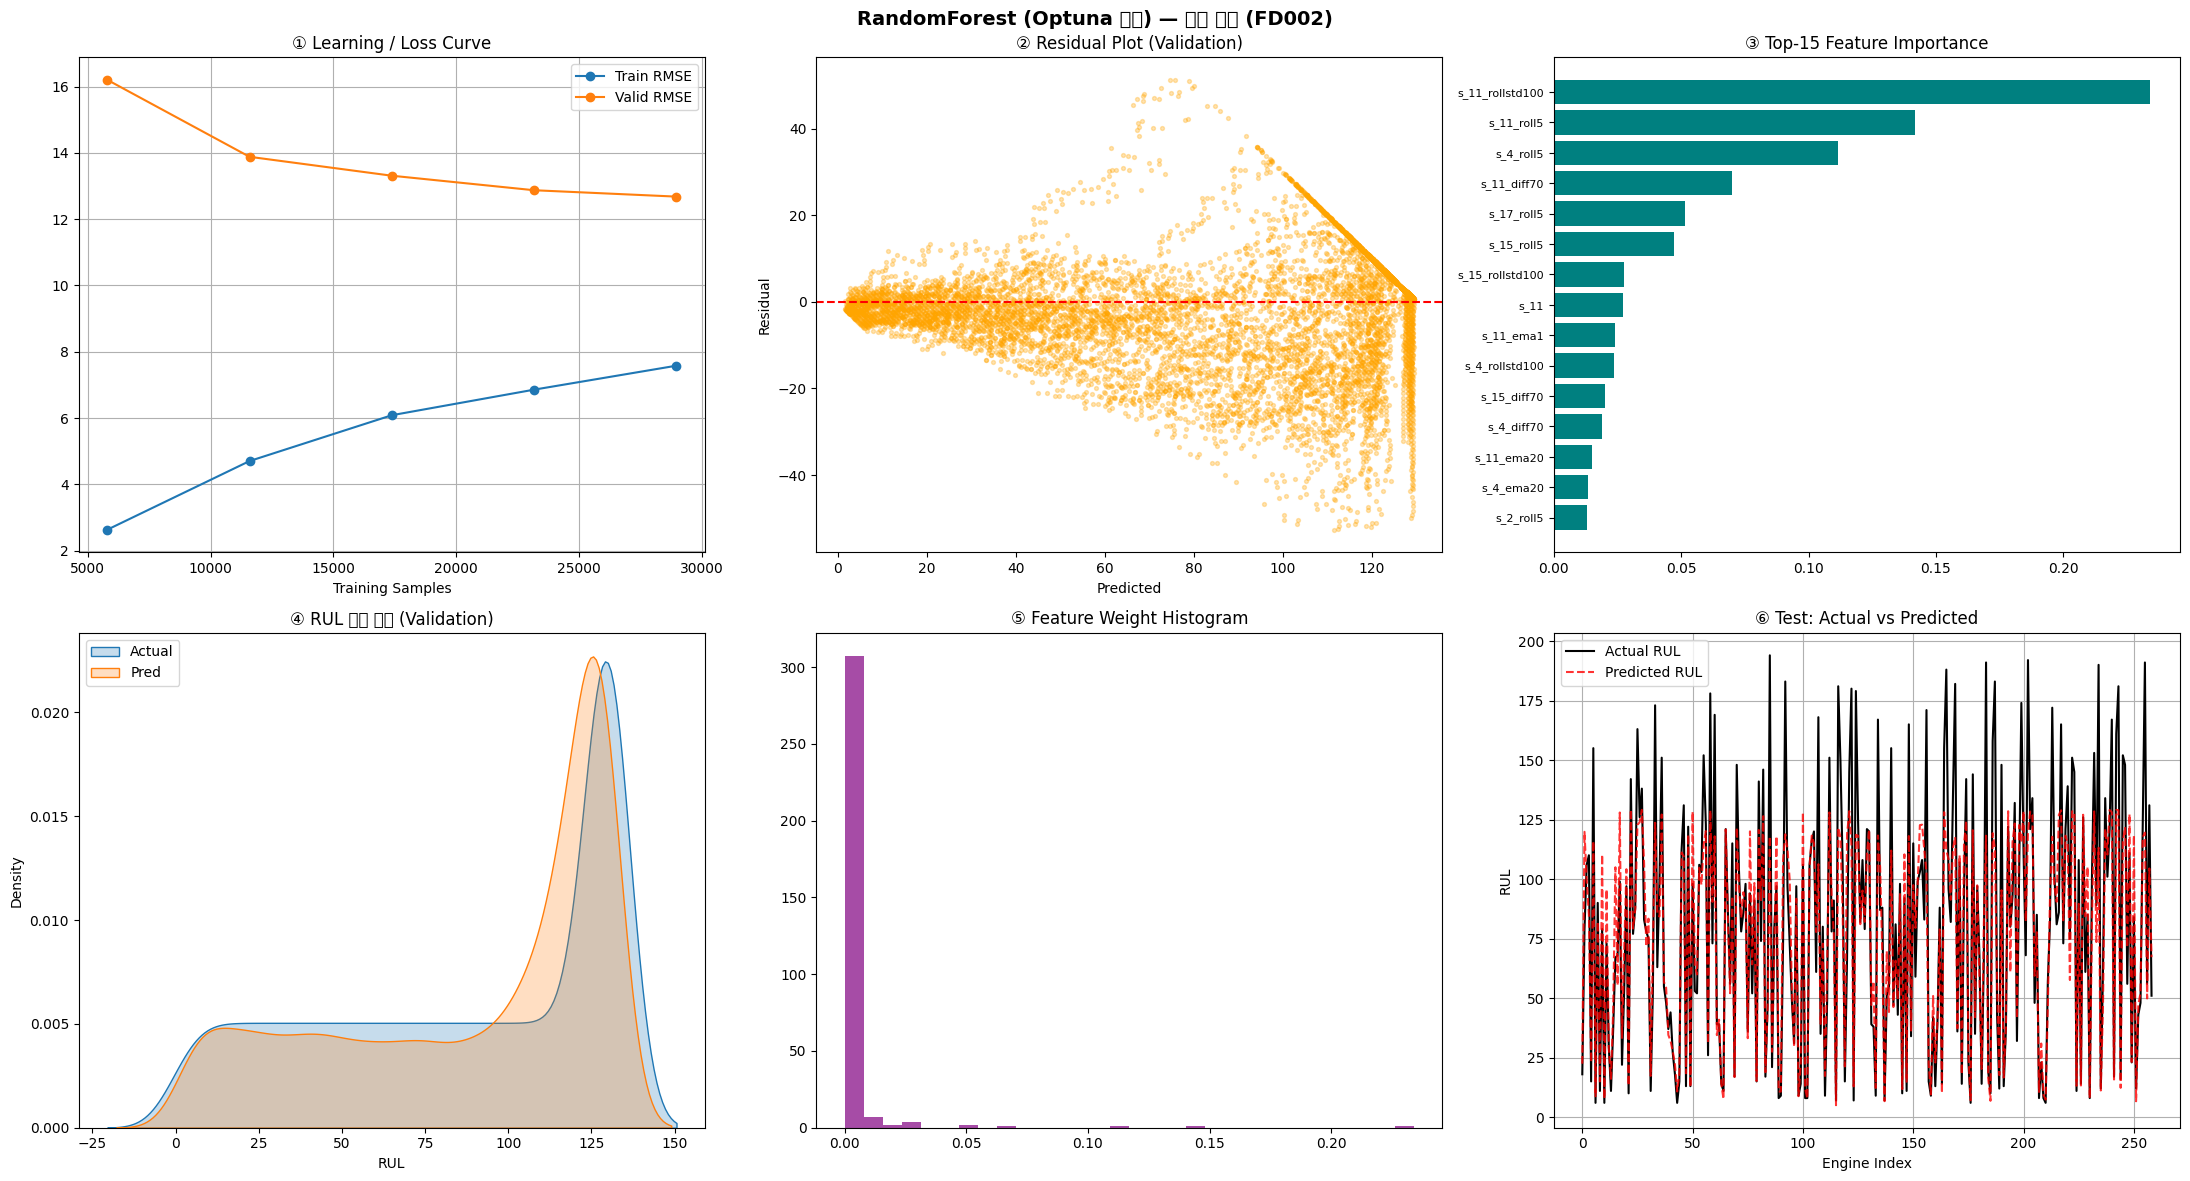

In [30]:
# 1. Random Forest 모델만 선택
model_name = 'RandomForest' 

if model_name in BEST_MODELS:
    print(f"\n{'='*60}")
    print(f"🌲 [{model_name}] 모델 재평가 및 시각화 시작")
    print(f"{'='*60}")

    current_model = BEST_MODELS[model_name]
    res_info      = ALL_RESULTS[model_name]
    
    # RF는 Tree 계열이지만 Boosting은 아님
    is_tree  = True
    is_boost = False 

    print(f'🎯 최적 파라미터: {res_info["params"]}')

    # Random Forest는 개별 트리를 독립적으로 학습하므로 
    # XGB/LGB처럼 eval_set을 통한 실시간 eval_results를 생성하지 않습니다.
    eval_results_refit = None

    # 전체 데이터(X_train)로 최종 학습 확인 후 시각화 함수 호출
    # (이미 BEST_MODELS에 학습된 상태로 들어있다면 .fit을 생략해도 됩니다)
    current_model.fit(X_train, y_train)

    evaluate_full_pipeline(
        current_model,
        f'{model_name} (Optuna 최적)',
        is_tree=is_tree,
        is_boosting=is_boost,
        eval_results=eval_results_refit  # RF는 보통 None으로 전달
    )
else:
    print(f"❌ BEST_MODELS 내에 {model_name} 결과가 존재하지 않습니다.")

## 12. Optuna 최적 파라미터로 재시각화 (모든 모델 루프)


🚀 [Ridge] 모델 재평가 및 시각화 시작
🎯 최적 파라미터: {'alpha': 3.764984064353955, 'solver': 'lsqr'}

 🏆 Ridge (Optuna 최적) 평가 결과 (FD002)
 [Train] RMSE=12.5409 | MAE=9.3661 | R2=0.9166 | NASA=104647.4
 [Valid] RMSE=13.6874 | MAE=10.0975 | R2=0.9010 | NASA=37887.2
 [Test ] RMSE=24.3281 | MAE=18.0848 | R2=0.7954 | NASA=3942.4


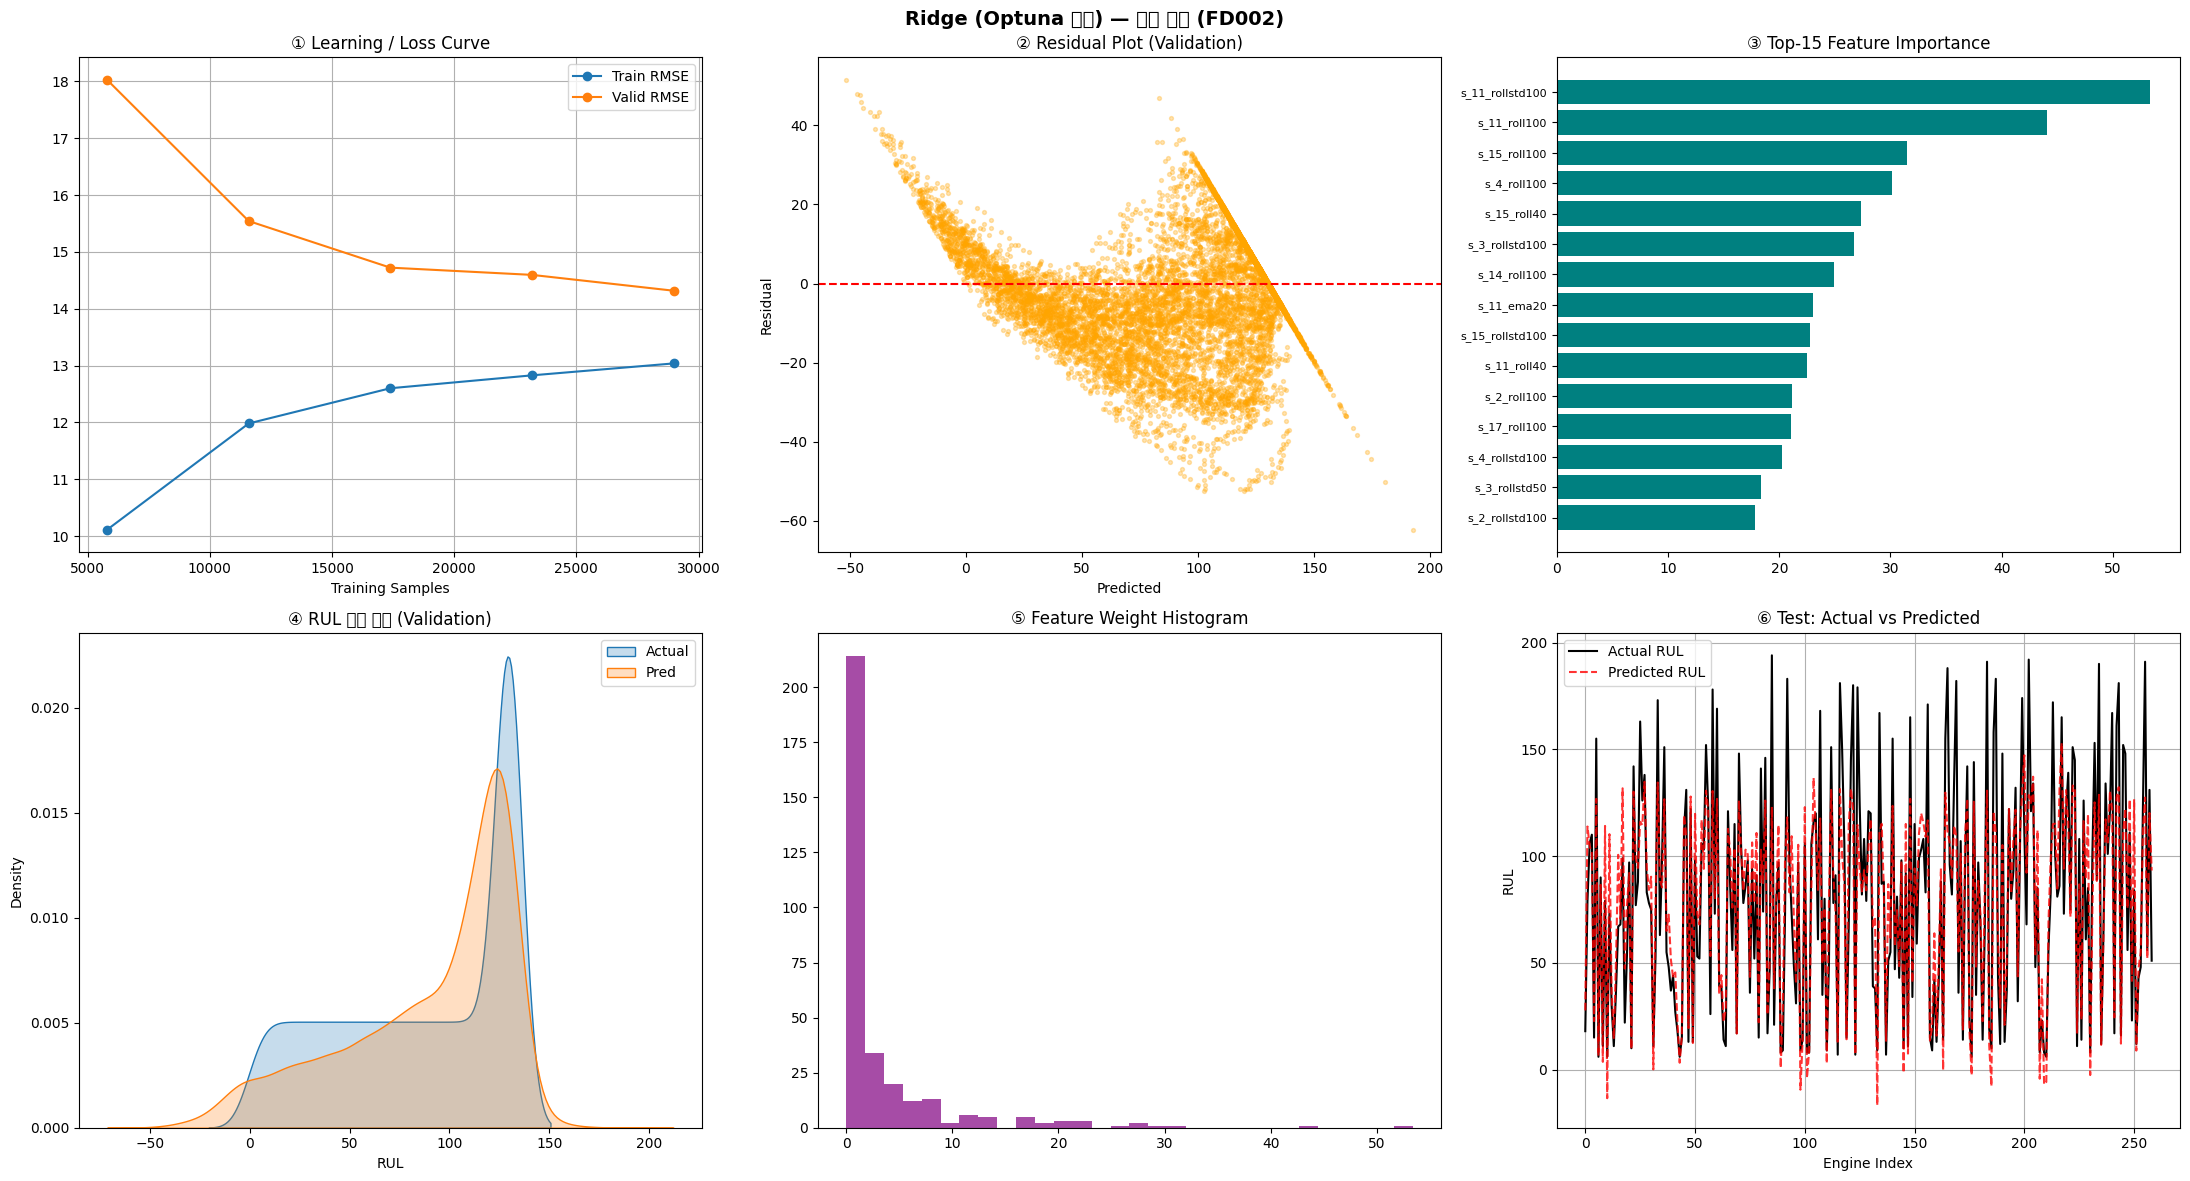


🚀 [Lasso] 모델 재평가 및 시각화 시작
🎯 최적 파라미터: {'alpha': 0.005702567263477803, 'selection': 'cyclic'}

 🏆 Lasso (Optuna 최적) 평가 결과 (FD002)
 [Train] RMSE=12.6047 | MAE=9.4432 | R2=0.9157 | NASA=106177.7
 [Valid] RMSE=13.6573 | MAE=10.0893 | R2=0.9014 | NASA=37709.7
 [Test ] RMSE=24.3514 | MAE=18.1169 | R2=0.7950 | NASA=3923.5


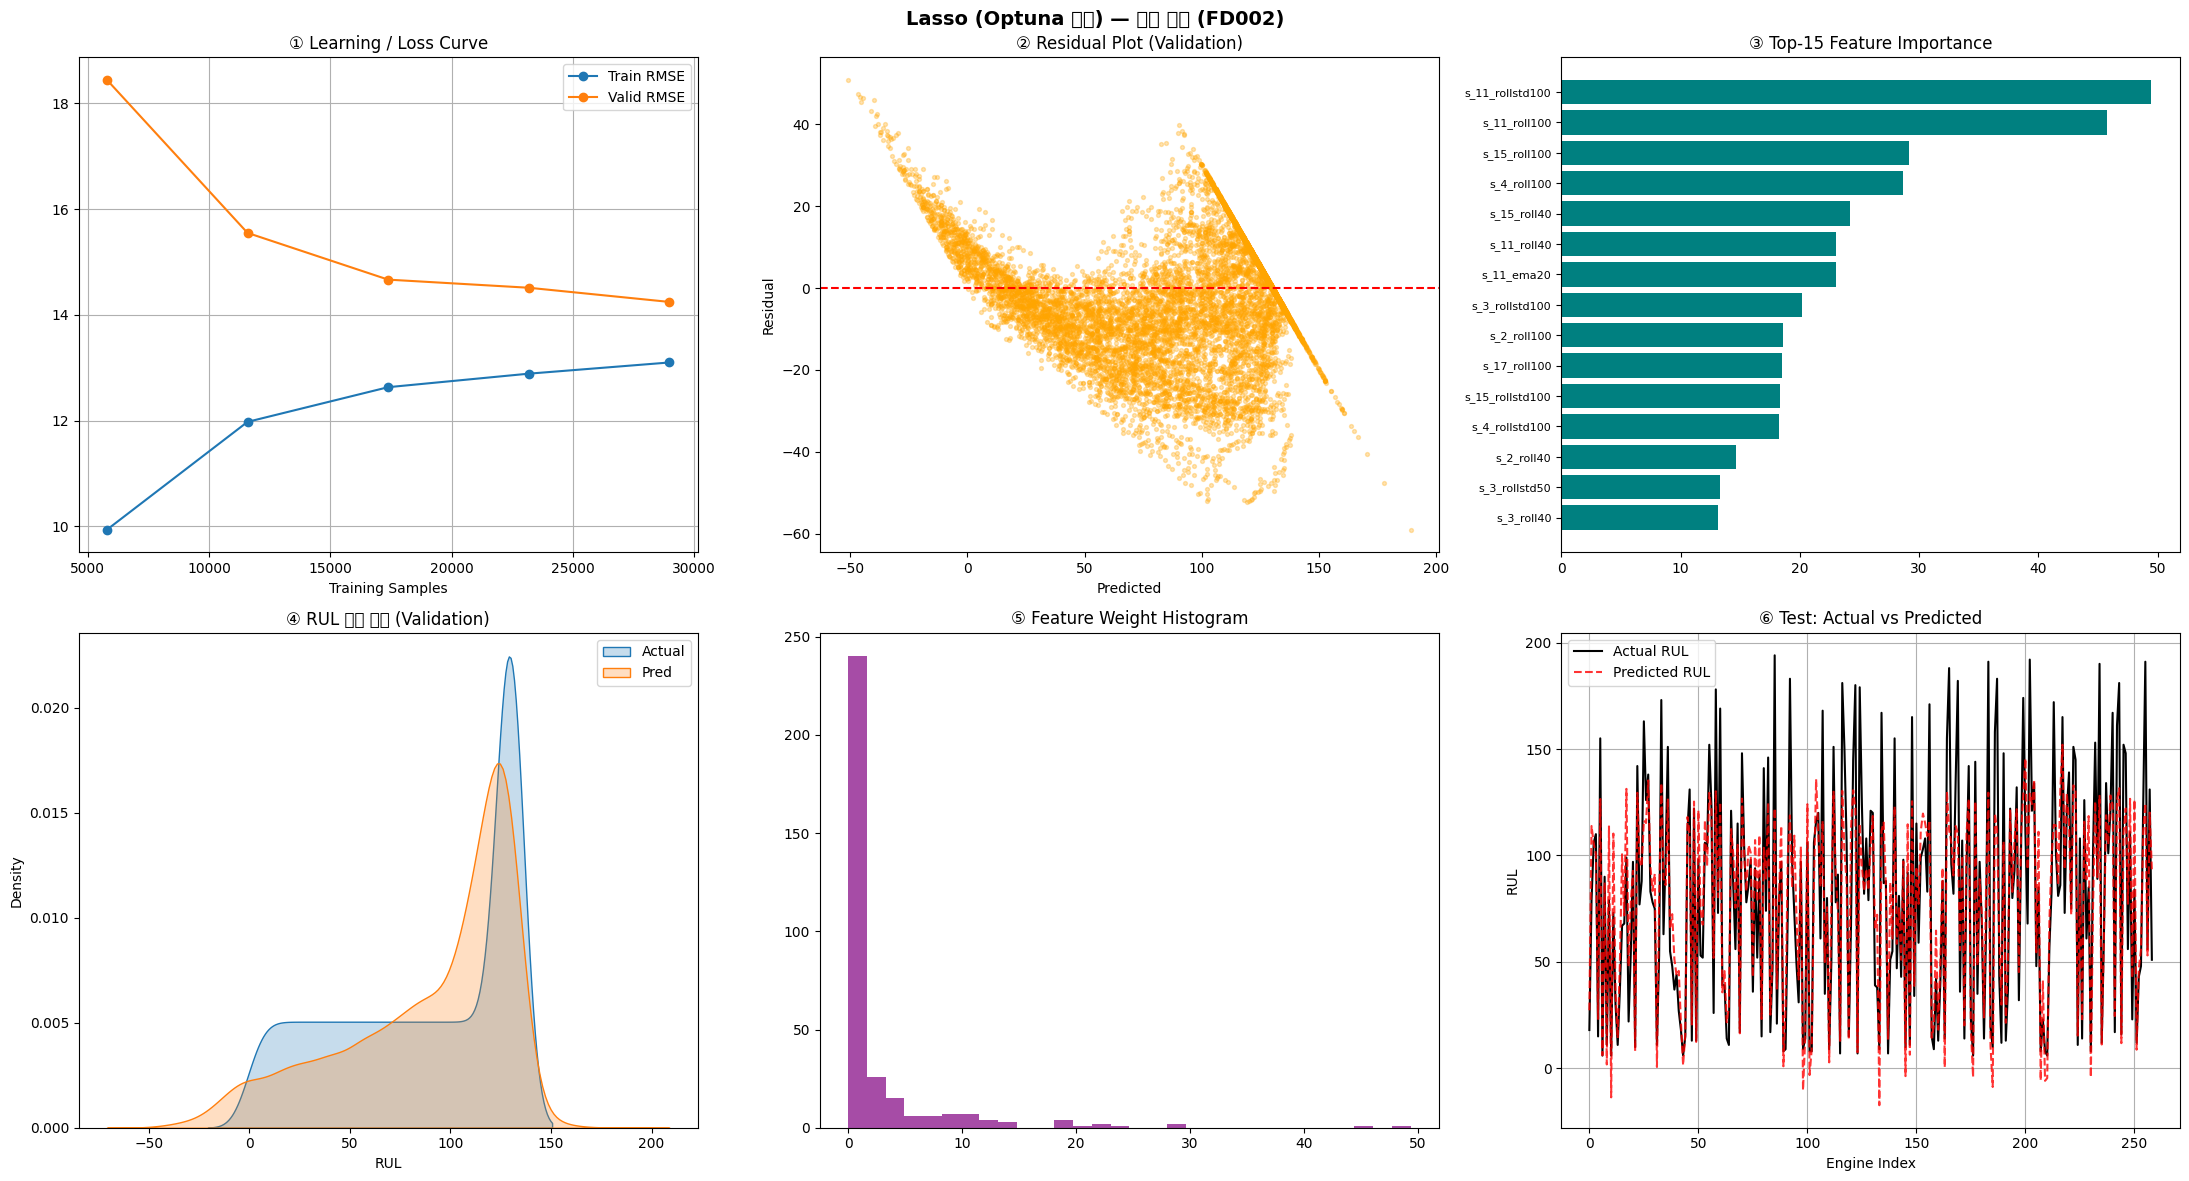


🚀 [ElasticNet] 모델 재평가 및 시각화 시작
🎯 최적 파라미터: {'alpha': 0.0017722751943993484, 'l1_ratio': 0.8354893797801306, 'selection': 'random'}

 🏆 ElasticNet (Optuna 최적) 평가 결과 (FD002)
 [Train] RMSE=12.6018 | MAE=9.4444 | R2=0.9157 | NASA=106127.3
 [Valid] RMSE=13.6687 | MAE=10.1096 | R2=0.9013 | NASA=37501.2
 [Test ] RMSE=24.4181 | MAE=18.1848 | R2=0.7938 | NASA=3990.4


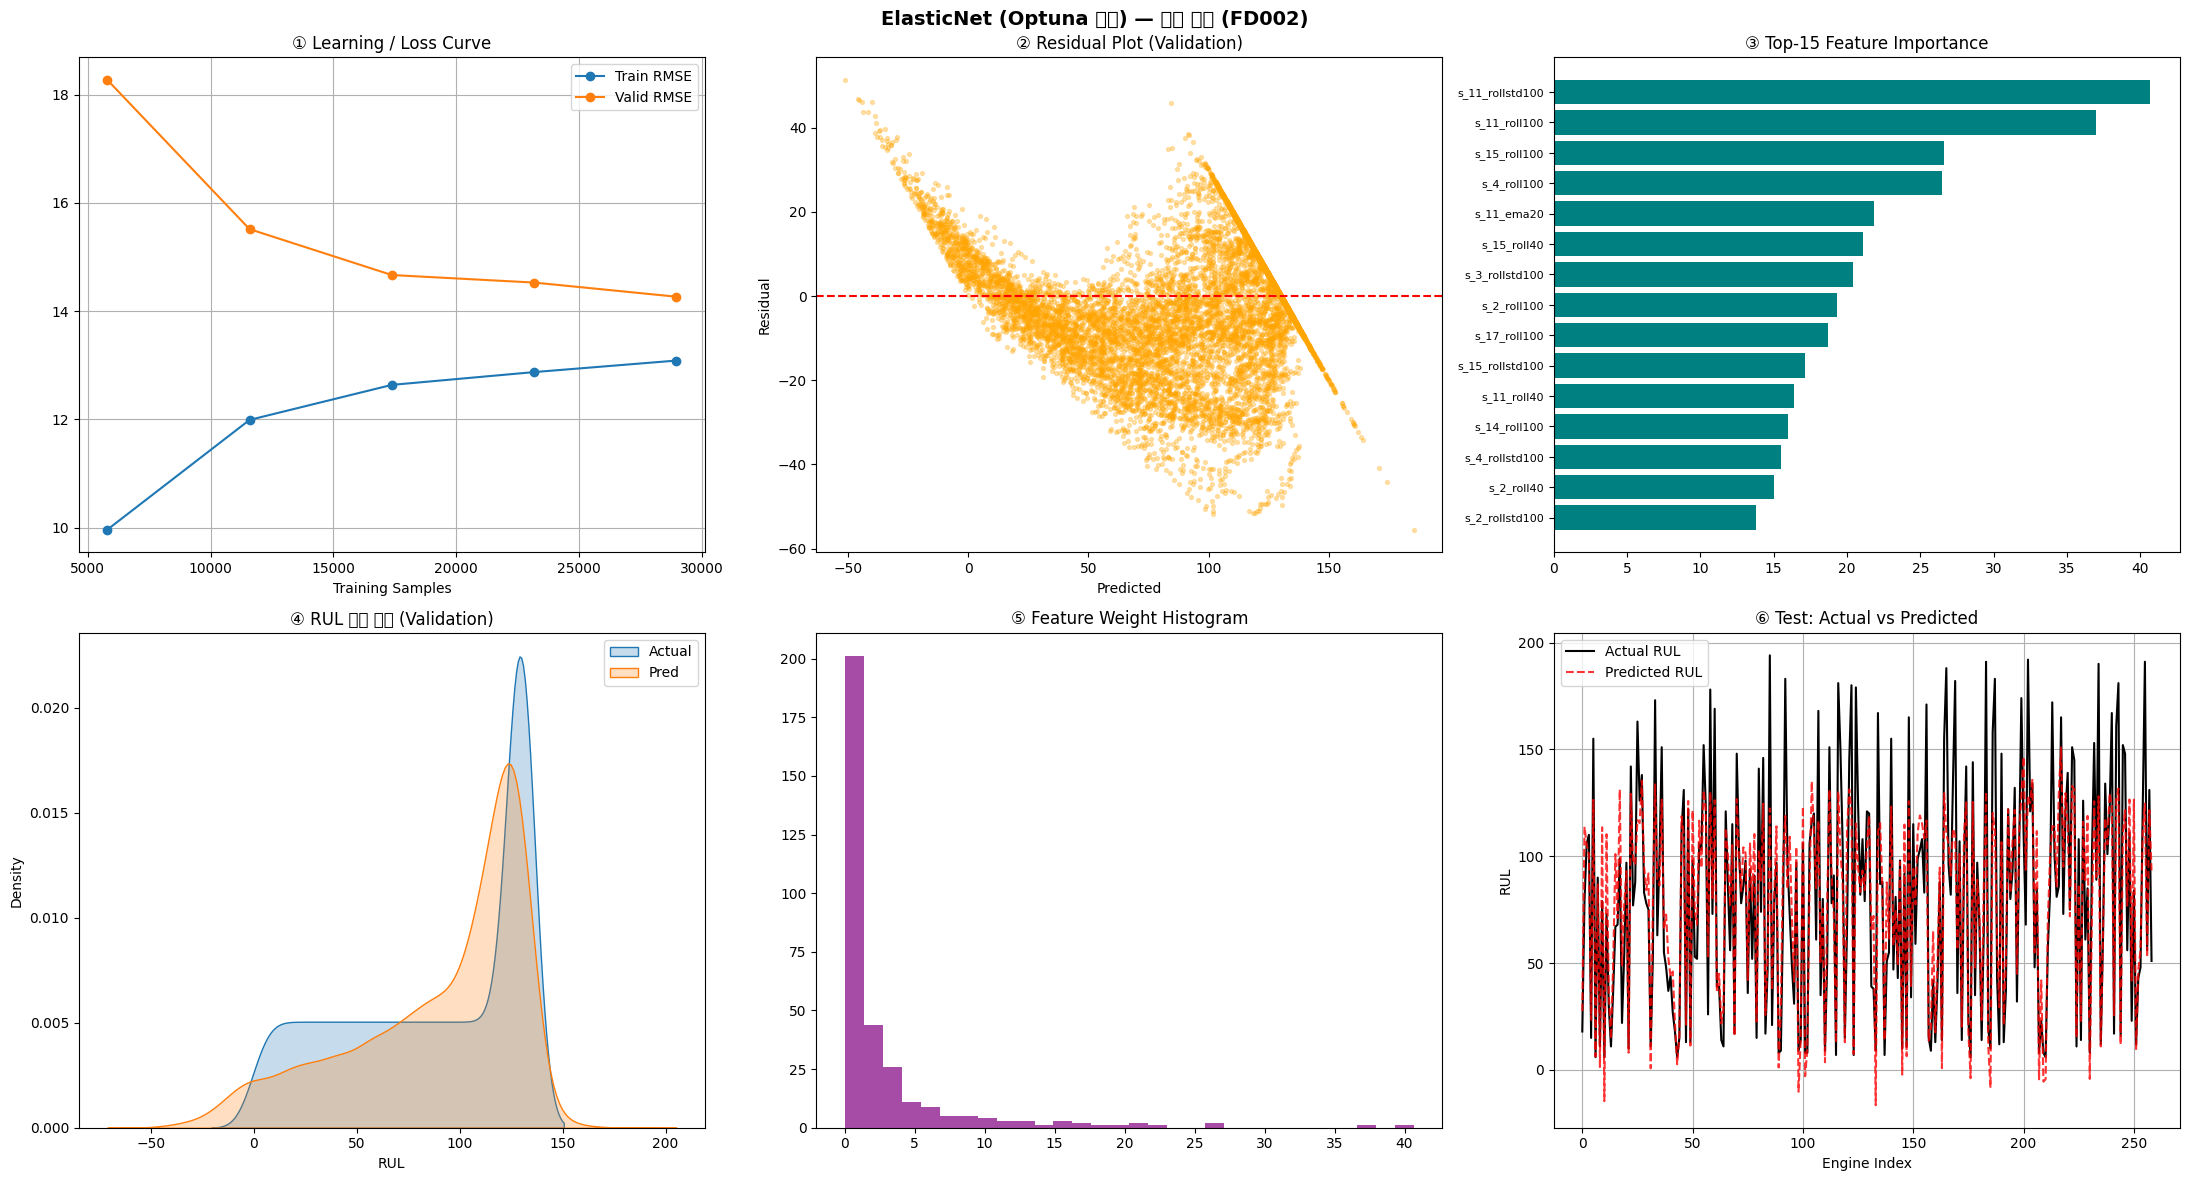


🚀 [XGBoost] 모델 재평가 및 시각화 시작
🎯 최적 파라미터: {'n_estimators': 621, 'max_depth': 6, 'learning_rate': 0.017491747763580135, 'subsample': 0.5496424269188376, 'colsample_bytree': 0.5140859759307262, 'reg_alpha': 0.6759193998482651, 'reg_lambda': 0.0029559850179357357}

 🏆 XGBoost (Optuna 최적) 평가 결과 (FD002)
 [Train] RMSE=8.0892 | MAE=5.5294 | R2=0.9653 | NASA=47972.2
 [Valid] RMSE=11.9530 | MAE=8.2097 | R2=0.9245 | NASA=29124.7
 [Test ] RMSE=23.6226 | MAE=15.6572 | R2=0.8071 | NASA=4198.5


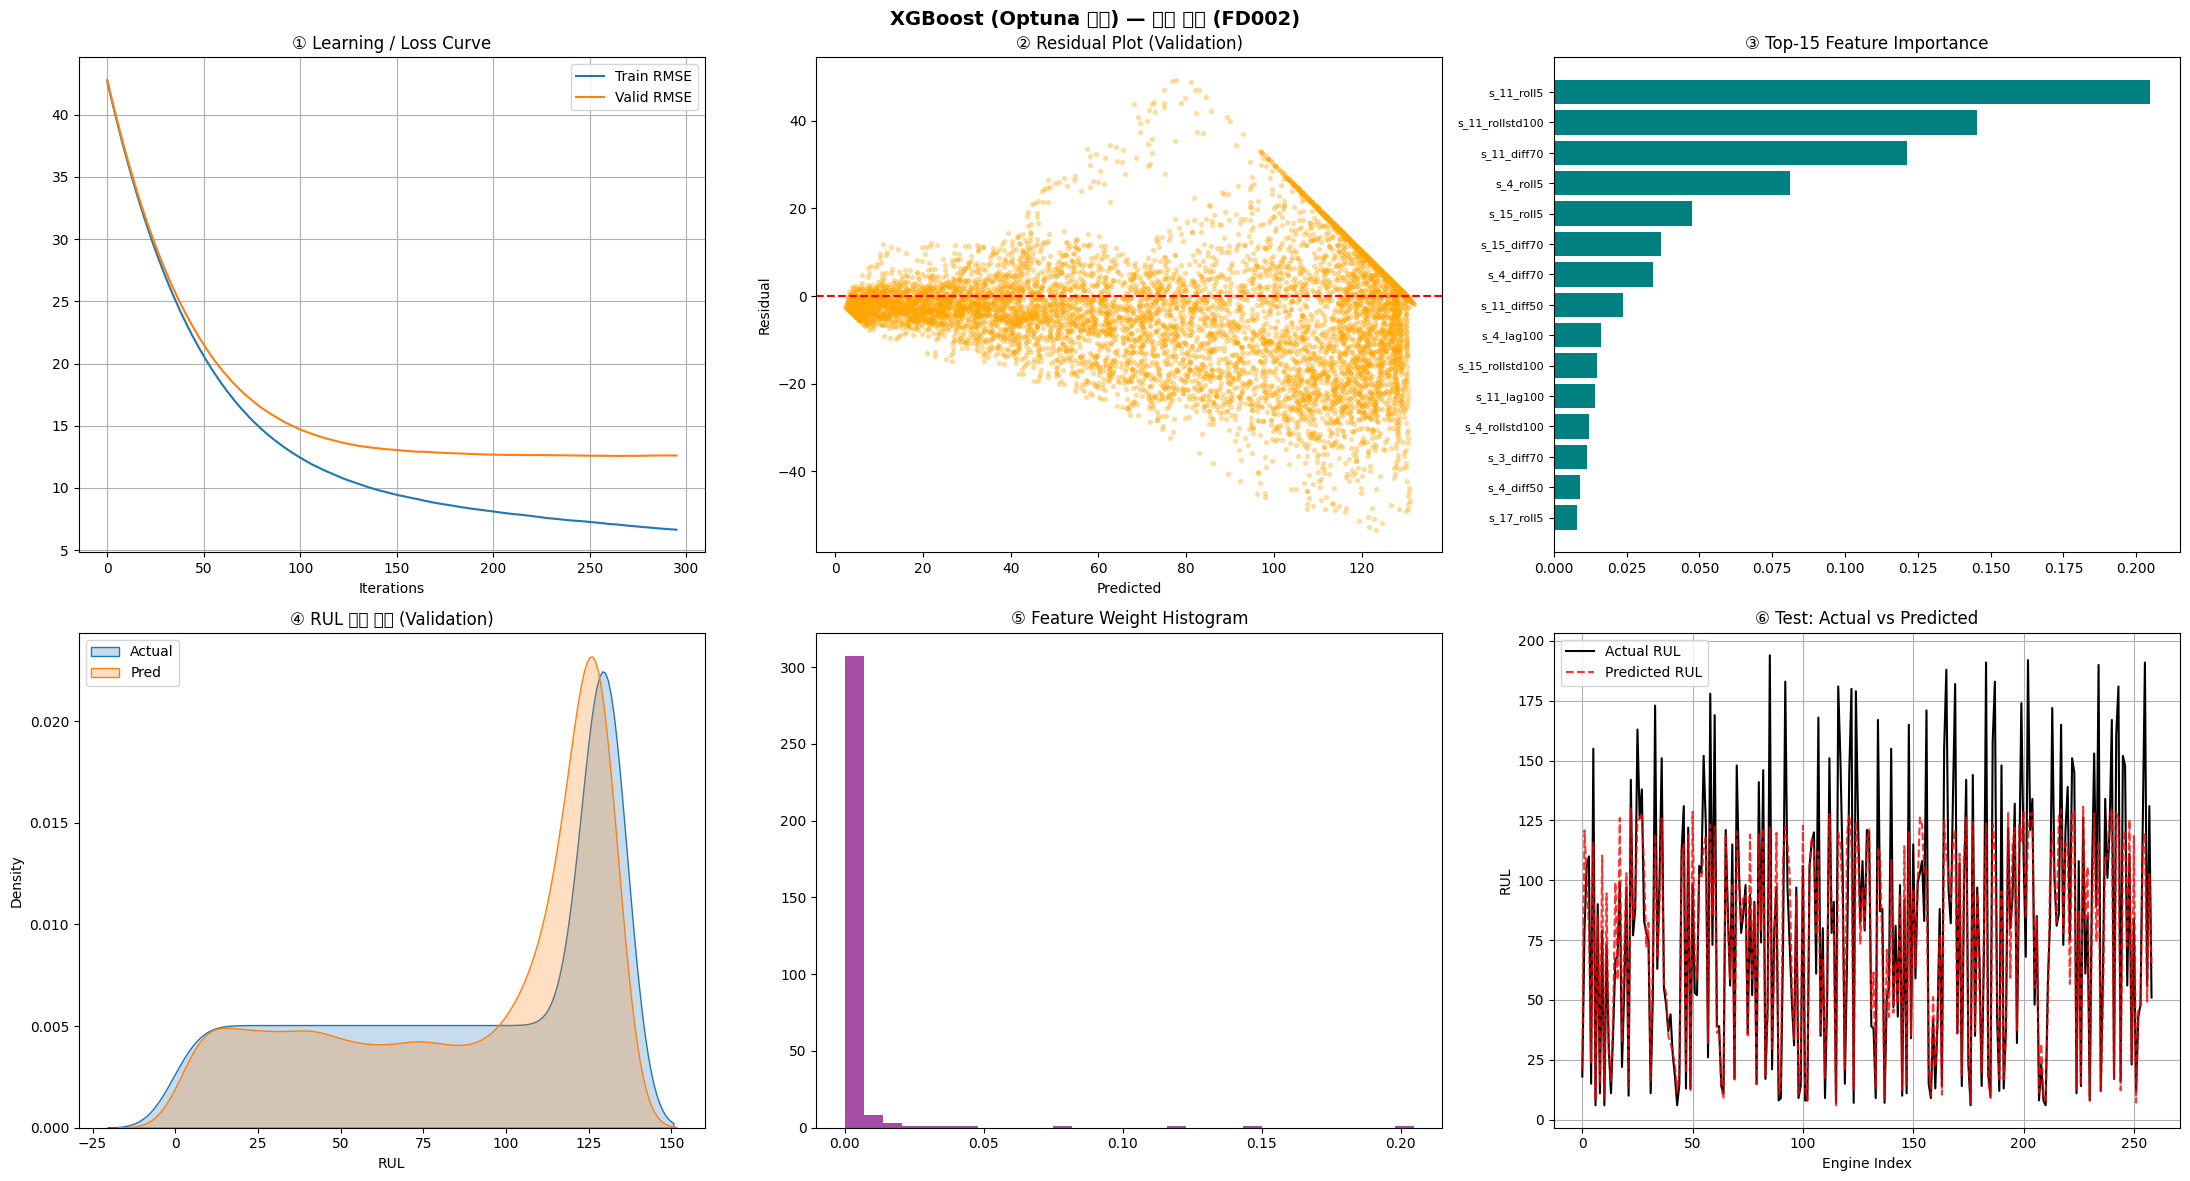


🚀 [LightGBM] 모델 재평가 및 시각화 시작
🎯 최적 파라미터: {'n_estimators': 677, 'max_depth': 6, 'learning_rate': 0.010775228020342231, 'num_leaves': 181, 'subsample': 0.605081846741258, 'colsample_bytree': 0.5488007912473831, 'reg_alpha': 0.0003747128797117446, 'reg_lambda': 1.4051040874661587e-06}

 🏆 LightGBM (Optuna 최적) 평가 결과 (FD002)
 [Train] RMSE=7.4782 | MAE=4.9154 | R2=0.9703 | NASA=41613.0
 [Valid] RMSE=11.8994 | MAE=8.0994 | R2=0.9252 | NASA=28789.2
 [Test ] RMSE=23.7757 | MAE=15.8292 | R2=0.8045 | NASA=4286.9


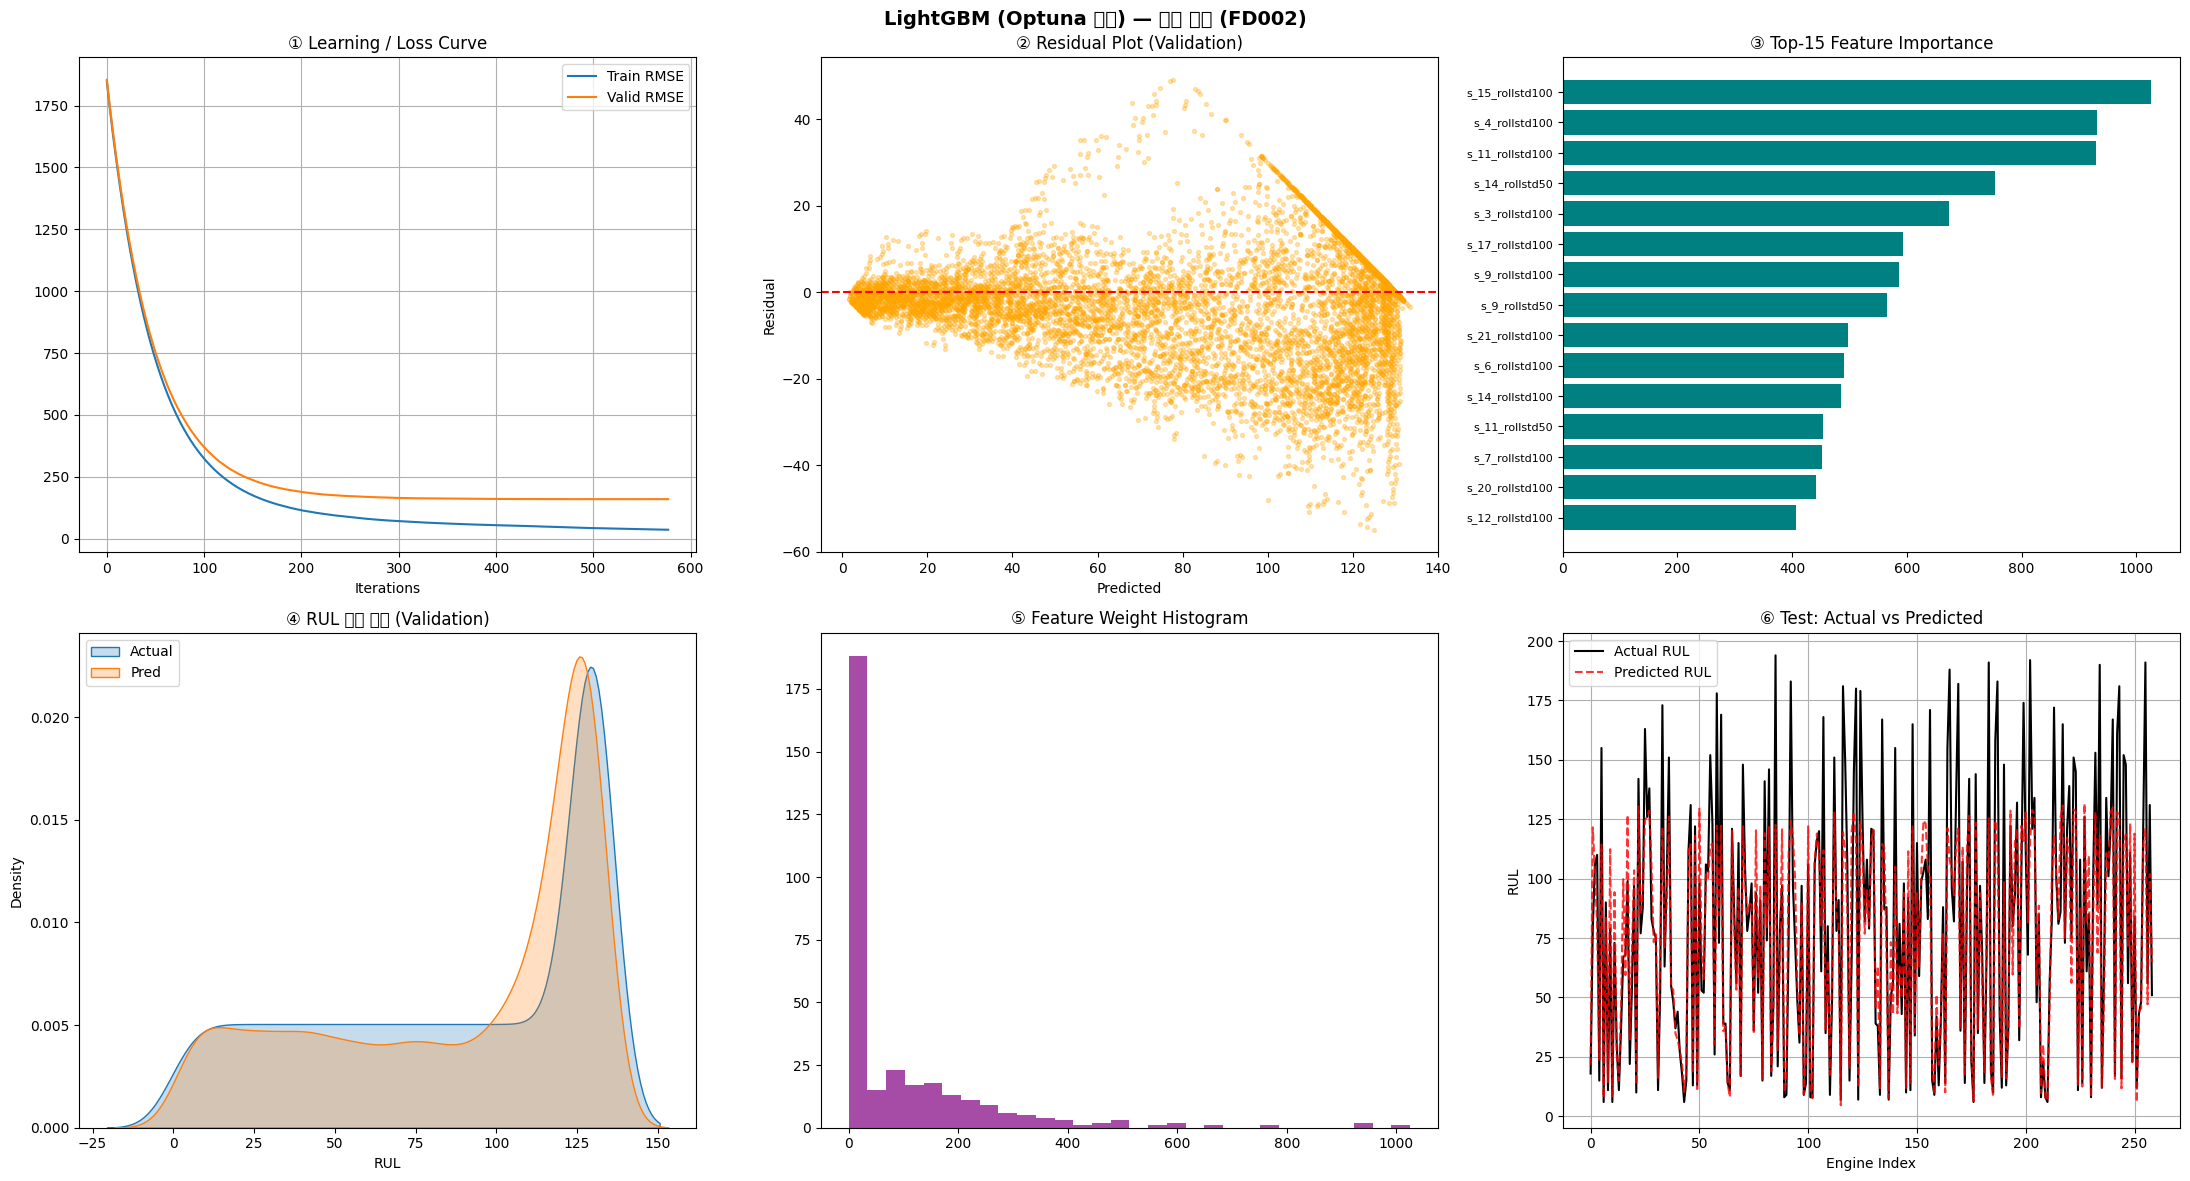

In [25]:
for model_name in BEST_MODELS.keys():
    print(f"\n{'='*60}")
    print(f"🚀 [{model_name}] 모델 재평가 및 시각화 시작")
    print(f"{'='*60}")

    current_model = BEST_MODELS[model_name]
    res_info      = ALL_RESULTS[model_name]
    is_tree       = res_info['type'] == 'tree'
    is_boost      = model_name in ('XGBoost', 'LightGBM')

    print(f'🎯 최적 파라미터: {res_info["params"]}')

    eval_results_refit = None

    if is_boost:
        X_in_val, y_in_val, X_iv_val, y_iv_val = _inner_split(
            X_train.values, y_train.values, groups)
        X_in = pd.DataFrame(X_in_val, columns=ML_FEATURES)
        X_iv = pd.DataFrame(X_iv_val, columns=ML_FEATURES)
        y_in, y_iv = pd.Series(y_in_val), pd.Series(y_iv_val)

        if model_name == 'XGBoost':
            current_model.fit(X_in, y_in,
                              eval_set=[(X_in, y_in), (X_iv, y_iv)],
                              verbose=False)
            r2 = current_model.evals_result()
            m_key = list(r2['validation_0'].keys())[0]
            eval_results_refit = {'train': r2['validation_0'][m_key],
                                  'valid': r2['validation_1'][m_key]}
        elif model_name == 'LightGBM':
            current_model.fit(X_in, y_in,
                              eval_set=[(X_in, y_in), (X_iv, y_iv)],
                              callbacks=[lgb.early_stopping(30, verbose=False),
                                         lgb.log_evaluation(0)])
            r2 = current_model.evals_result_
            train_key = 'training' if 'training' in r2 else 'valid_0'
            m_key = 'rmse' if 'rmse' in r2[train_key] else list(r2[train_key].keys())[0]
            eval_results_refit = {'train': r2[train_key][m_key],
                                  'valid': r2['valid_1'][m_key]}

    evaluate_full_pipeline(
        current_model,
        f'{model_name} (Optuna 최적)',
        is_tree=is_tree,
        is_boosting=is_boost,
        eval_results=eval_results_refit
    )

## 13. 결과 저장 (옵션)

In [1]:
# ============================================================
# 셀 40 (마지막 셀) — 기존 코드를 아래로 통째 교체
# ============================================================
SUBSET = CONFIG['subset']
USE_CLUSTERING = data['use_clustering']

OUTPUT_DIR = Path(f'preprocessed_{SUBSET}')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── 1. 전처리 데이터 CSV 저장 (기존) ──
train_ml.to_csv(OUTPUT_DIR / f'{SUBSET}_ml_subtrain.csv', index=False)
valid_ml.to_csv(OUTPUT_DIR / f'{SUBSET}_ml_valid.csv',    index=False)
test_ml.to_csv( OUTPUT_DIR / f'{SUBSET}_ml_test.csv',     index=False)

# ── 2. 모델/스케일러 저장 (기존) ──
if USE_CLUSTERING:
    joblib.dump(data['op_scaler'], OUTPUT_DIR / f'{SUBSET}_op_scaler.pkl')
    joblib.dump(data['kmeans'],    OUTPUT_DIR / f'{SUBSET}_kmeans.pkl')
    joblib.dump(data['scalers'],   OUTPUT_DIR / f'{SUBSET}_scalers_by_cluster.pkl')
else:
    joblib.dump(data['scalers'],   OUTPUT_DIR / f'{SUBSET}_scaler.pkl')

# ── 3. 모델 결과 요약 저장 (기존) ──
summary_df.to_csv(OUTPUT_DIR / f'{SUBSET}_model_summary.csv', index=False)

# ============================================================
# ★ 시연용 추가 저장 (대시보드에서 사용)
# ============================================================

# 3-1) 학습된 모델 3종 저장
# models_for_demo = {
#     'LGBM': model_lgb,
#     'XGB':  model_xgb,
#     'RF':   model_rf,
# }
# joblib.dump(models_for_demo, OUTPUT_DIR / f'{SUBSET}_models.pkl')

models_for_demo = {
    'LGBM': BEST_MODELS['LightGBM'],
    'XGB':  model_xgb, #BEST_MODELS['XGBoost'],
    'RF': BEST_MODELS['RandomForest'], 
}
joblib.dump(models_for_demo, OUTPUT_DIR / f'{SUBSET}_models.pkl')


# 3-2) 메타 정보 저장 (앱이 로드해서 사용)
meta = {
    'subset':         SUBSET,
    'ml_features':    list(ML_FEATURES),
    'rul_cap':        CONFIG['rul_cap'],
    'use_clustering': bool(USE_CLUSTERING),
    'unit_list':      sorted(test_ml['unit_nr'].unique().tolist()),
    'sensor_cols':    list(data['useful_sensors']),
}
with open(OUTPUT_DIR / f'{SUBSET}_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

# 3-3) 정답 RUL 저장
rul_df.to_csv(OUTPUT_DIR / f'{SUBSET}_rul.csv', index=False)

print(f'\n✅ {SUBSET} 결과 저장 완료 → {OUTPUT_DIR.resolve()}')
print(f'   파일 수: {len(list(OUTPUT_DIR.iterdir()))}개')
print(f'   📦 시연용 파일: {SUBSET}_models.pkl, {SUBSET}_meta.json, {SUBSET}_rul.csv')
print(f'\n💡 다음 단계: CONFIG[\'subset\']을 FD002/FD003/FD004로 바꿔서 노트북 다시 실행')

NameError: name 'CONFIG' is not defined

In [ ]:
# ============================================================
# 6개 모델 Optuna 최적 파라미터 및 성능(RMSE & NASA Score) 출력
# ============================================================

print(f"{'='*80}")
print(f"🚀 [전체 6개 모델 Optuna 최적화 결과 요약]")
print(f"   데이터셋: {CONFIG['subset']} | 정렬 기준: {OPTUNA_METRIC.upper()}")
print(f"{'='*80}")

for model_name, result in ALL_RESULTS.items():
    print(f"\n✅ 모델: [{model_name}]")
    
    # 1. 성능 지표 추출 (RMSE & NASA Score)
    cv_rmse = result.get('cv_rmse', 0)
    cv_nasa = result.get('cv_nasa', 0)
    
    # 테스트 세트 지표
    test_mets = result.get('test_metrics', {})
    test_rmse = test_mets.get('RMSE', 0)
    test_nasa = test_mets.get('NASA_Score', 0)
    
    print(f"   [Performance - CV]   RMSE: {cv_rmse:.4f} | NASA Score: {cv_nasa:.2f}")
    print(f"   [Performance - Test] RMSE: {test_rmse:.4f} | NASA Score: {test_nasa:.2f}")
    
    # 2. 최적 하이퍼파라미터 출력
    params = result.get('params', {})
    print(f"   [Best Parameters]")
    if params:
        for p_name, p_value in params.items():
            if isinstance(p_value, float):
                print(f"     └ {p_name}: {p_value:.6f}")
            else:
                print(f"     └ {p_name}: {p_value}")
    else:
        print("     └ (저장된 파라미터 없음)")
        
    print(f"   [Time] 학습 소요 시간: {result.get('fit_seconds', 0):.2f}s")

print(f"\n{'='*80}")
# summary_df 기준 1위 모델 요약
best_row = summary_df.iloc[0]
print(f"🏆 종합 최우수 모델: {best_row['Model']}")
print(f"   Test RMSE: {best_row['Test_RMSE']:.4f} | Test NASA Score: {best_row['Test_NASA']:.2f}")
print(f"{'='*80}")

🚀 [전체 6개 모델 Optuna 최적화 결과 요약]


NameError: name 'CONFIG' is not defined

In [3]:
# ============================================================
# 셀 40 (최종본) — BEST_MODELS 및 ALL_RESULTS 기반 통합 저장
# ============================================================
import json
import joblib
from pathlib import Path

SUBSET = CONFIG['subset']
USE_CLUSTERING = data['use_clustering']

OUTPUT_DIR = Path(f'preprocessed_{SUBSET}')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── 1. 전처리 데이터 CSV 저장 ──
train_ml.to_csv(OUTPUT_DIR / f'{SUBSET}_ml_subtrain.csv', index=False)
valid_ml.to_csv(OUTPUT_DIR / f'{SUBSET}_ml_valid.csv',    index=False)
test_ml.to_csv( OUTPUT_DIR / f'{SUBSET}_ml_test.csv',     index=False)

# ── 2. 스케일러 및 클러스터링 도구 저장 ──
if USE_CLUSTERING:
    joblib.dump(data['op_scaler'], OUTPUT_DIR / f'{SUBSET}_op_scaler.pkl')
    joblib.dump(data['kmeans'],    OUTPUT_DIR / f'{SUBSET}_kmeans.pkl')
    joblib.dump(data['scalers'],   OUTPUT_DIR / f'{SUBSET}_scalers_by_cluster.pkl')
else:
    joblib.dump(data['scalers'],   OUTPUT_DIR / f'{SUBSET}_scaler.pkl')

# ── 3. 모델 결과 요약 저장 (성능 지표 리포트) ──
summary_df.to_csv(OUTPUT_DIR / f'{SUBSET}_model_summary.csv', index=False)

# ── 4. Optuna 최적 하이퍼파라미터 저장 ──
# ALL_RESULTS 딕셔너리에 저장된 각 모델의 best_params를 추출합니다.
# (구조: ALL_RESULTS['LightGBM']['best_params'])
best_params_to_save = {}
for model_name, results in ALL_RESULTS.items():
    if 'best_params' in results:
        best_params_to_save[model_name] = results['best_params']

with open(OUTPUT_DIR / f'{SUBSET}_best_params.json', 'w', encoding='utf-8') as f:
    json.dump(best_params_to_save, f, indent=2, ensure_ascii=False)

# ── 5. 학습된 6종 모델 객체 통합 저장 ──
# BEST_MODELS에 담긴 6개 모델(LGBM, XGB, RF, Ridge, Lasso, Enet 등)을 한 번에 저장합니다.
if BEST_MODELS:
    joblib.dump(BEST_MODELS, OUTPUT_DIR / f'{SUBSET}_models.pkl')
else:
    print("⚠️ 경고: BEST_MODELS가 비어있습니다. 모델 파일이 생성되지 않습니다.")

# ── 6. 메타 정보 저장 (대시보드/앱 로드용) ──
meta = {
    'subset':         SUBSET,
    'ml_features':    list(ML_FEATURES),
    'rul_cap':        CONFIG['rul_cap'],
    'use_clustering': bool(USE_CLUSTERING),
    'unit_list':      sorted(test_ml['unit_nr'].unique().tolist()),
    'sensor_cols':    list(data['useful_sensors']),
    'models_saved':   list(BEST_MODELS.keys())
}
with open(OUTPUT_DIR / f'{SUBSET}_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

# ── 7. 정답 RUL 저장 ──
rul_df.to_csv(OUTPUT_DIR / f'{SUBSET}_rul.csv', index=False)

print(f'\n✅ {SUBSET} 결과 저장 완료 → {OUTPUT_DIR.resolve()}')
print(f'   📦 저장된 모델({len(BEST_MODELS)}종): {", ".join(BEST_MODELS.keys())}')
print(f'   📂 생성 파일: {SUBSET}_best_params.json, {SUBSET}_models.pkl, {SUBSET}_meta.json')

NameError: name 'CONFIG' is not defined